# Phase 0 : Use Case


# Cas d’usage : Estimation automatique du prix de vente pour une plateforme immobilière en ligne

## Problème métier

L’objectif principal de notre plateforme est de permettre à un **propriétaire particulier** souhaitant vendre son bien de connaître immédiatement une **estimation objective de son prix**. Cette estimation permet :

* D’instaurer **confiance** chez le vendeur.
* De **réduire les délais de vente** en affichant un prix réaliste dès le départ.
* D’**automatiser** le processus pour limiter la mobilisation de ressources humaines coûteuses.

Dans ce cadre, nous intégrons un **modèle de machine learning** directement dans notre interface, permettant à l’utilisateur d’obtenir une **estimation instantanée** dès qu’il renseigne les caractéristiques de son bien.

---

## Rôle des données

Le jeu de données Kaggle *House Prices: Advanced Regression Techniques* constitue une base réaliste pour construire ce système :

* Il contient **79 variables descriptives** (superficie, nombre de pièces, quartier, qualité des matériaux, etc.) et un prix de vente final.
* Il reflète fidèlement les données que notre plateforme peut collecter via un formulaire rempli par l’utilisateur.

Ces données seront utilisées pour entraîner notre modèle à **prédire un prix à partir de caractéristiques connues**. Pour rester fiable, le modèle sera mis à jour régulièrement avec **de nouvelles ventes enregistrées** sur la plateforme.

---

## Acteurs concernés

1. **Vendeurs particuliers**

   * Utilisent l’outil pour obtenir une estimation fiable et gratuite.
   * Décident ensuite de mettre leur bien en ligne avec plus de sérénité.

2. **Plateforme**

   * Propose une **expérience utilisateur innovante**.
   * Génère des leads qualifiés via l’usage de l’outil d’estimation.
   * Réduit les allers-retours de négociation.

3. **Équipe Data Science**

   * Conçoit, teste, valide et surveille le modèle.
   * S’appuie sur le cycle **CRISP-ML** pour garantir la robustesse et l’évolutivité du système.

---

## Intégration du modèle dans le processus métier

* Avant : le vendeur doit consulter un agent ou faire une estimation manuelle via comparaison ou intuition.
* Après : en quelques clics, il renseigne les informations sur son bien et obtient une **fourchette de prix automatisée** (ex. : "entre 260 000 € et 280 000 €").

Cela améliore l’expérience client, limite les frictions et **valorise la data comme avantage compétitif**.

---

## Objectifs business

| Objectif                              | Description                                                                          |
| ------------------------------------- | ------------------------------------------------------------------------------------ |
| Générer des leads                     | En fournissant une estimation gratuite, on attire des vendeurs sur notre plateforme. |
| Réduire les délais de vente           | Un bon positionnement tarifaire favorise une vente rapide.                           |
| Augmenter la satisfaction utilisateur | En proposant un outil rapide et fiable.                                              |
| Réduire les coûts internes            | Moins de besoins d’agents ou d’experts mobilisés.                                    |
| Innover et se différencier            | Proposer un service basé sur des techniques de machine learning modernes.            |

---

## Approche ML envisagée

1. **Modèles testés** : Régressions (linéaire, Lasso, Ridge), Arbres de décision, Random Forest, Gradient Boosting, XGBoost.
2. **Pipeline** : Nettoyage, encodage, normalisation, sélection de features.
3. **Évaluation** : RMSE, RMSLE (notamment car recommandé pour ce challenge).
4. **Validation croisée** : Utilisation de K-Fold pour limiter l’overfitting.
5. **Hyperparamètres** : Grid Search, Random Search ou méthode bayésienne selon le modèle.

---

## Étapes CRISP-ML suivies

| Phase                  | Action                                                                                                               |
| ---------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Idéation**           | Compréhension du problème métier et de l’opportunité commerciale.                                                    |
| **Data Understanding** | Exploration des variables les plus informatives (ex. : quartier, superficie, qualité).                               |
| **Design**             | Création d’un pipeline sklearn prêt à transformer `train.csv` et `test.csv`.                                         |
| **Model Engineering**  | Test de plusieurs modèles et tuning des hyperparamètres.                                                             |
| **Evaluation**         | Sélection du meilleur modèle pour la plateforme, interprétation métier.                                              |
| **Operation**          | Soumission sur Kaggle, puis intégration potentielle dans la plateforme avec monitoring, MLOps et contrôle de dérive. |

---

## Conclusion

Notre use case illustre une **application concrète du machine learning au service du business**. Grâce à l’outil d’estimation :

* Le vendeur bénéficie d’un service rapide, fiable et rassurant.
* La plateforme optimise son acquisition client et ses performances internes.
* Le modèle peut évoluer avec les tendances du marché et rester pertinent.



# Phase 1 : Phase d'idéation

## 1.1 Analyse du besoin métier et préparation des données

La mise en place d'un modèle d'estimation immobilière pour une plateforme en ligne implique d’abord une étape préliminaire cruciale consistant à préciser les attentes commerciales, à identifier précisément les indicateurs de performance du modèle, et à vérifier rigoureusement la qualité et la pertinence des données disponibles.

Dans ce contexte précis, cette étape garantit que notre solution automatisée répondra aux exigences des utilisateurs en fournissant une évaluation immobilière immédiate et objective. Elle permet également de confirmer que les informations récoltées via notre formulaire en ligne sont suffisamment qualitatives pour construire un modèle prédictif robuste et pertinent pour nos utilisateurs particuliers.


In [1]:
!pip install statsmodels
!pip install shap
!pip install -r requirements.txt

  Using cached ipython-9.2.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached jupyter_core-5.7.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached platformdirs-4.3.7-py3-none-any.whl.metadata (11 kB)
  Using cached pyzmq-26.4.0-cp312-cp312-win_amd64.whl.metadata (6.0 kB)
  Using cached tornado-6.4.2-cp38-abi3-win_amd64.whl.metadata (2.6 kB)
Using cached ipython-9.2.0-py3-none-any.whl (604 kB)
Using cached jupyter_core-5.7.2-py3-none-any.whl (28 kB)
Using cached platformdirs-4.3.7-py3-none-any.whl (18 kB)
Using cached pyzmq-26.4.0-cp312-cp312-win_amd64.whl (640 kB)
Using cached tornado-6.4.2-cp38-abi3-win_amd64.whl (438 kB)

  Attempting uninstall: tornado

    Found existing installation: tornado 6.5.1

    Uninstalling tornado-6.5.1:

      Successfully uninstalled tornado-6.5.1

   ---------------------------------------- 0/5 [tornado]
   ---------------------------------------- 0/5 [tornado]
   ---------------------------------------- 0/5 [tornado]
   ------------------------------

  You can safely remove it manually.
  You can safely remove it manually.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot

import math

In [3]:
plt.style.use('seaborn-v0_8') # pretty matplotlib plots

In [4]:
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')

### 1.1.1 Aperçu des données

In [5]:
train_raw.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### 1.1.1.4 Identification de la cible du modèle

Lorsqu’on débute une analyse prédictive, il est essentiel de comprendre précisément la variable à prédire. Dans notre cas, il s'agit du montant auquel un bien immobilier sera vendu, désigné par la variable **SalePrice**.

Pour répondre spécifiquement au besoin, notre modèle exploitera diverses caractéristiques immobilières telles que la superficie, la qualité des matériaux ou encore l’emplacement, afin de prévoir précisément cette valeur finale.

In [6]:
# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Ce résumé chiffré ne permet pas une interprétabilité visuelle directe, mais indique néanmoins que la majorité des biens sont vendus dans une fourchette de prix assez resserrée : environ 130 000 pour le premier quartile, une médiane à 163 000, une moyenne à 180 000 et un troisième quartile autour de 214 000. Cette différence entre médiane et moyenne révèle la présence de quelques biens particulièrement coûteux, qui influencent la moyenne vers des valeurs supérieures.

Ce type de situation est fréquent dans l'immobilier, où un grand nombre de biens se concentrent dans une tranche de prix moyenne, tandis que quelques propriétés d’exception font nettement grimper la moyenne.

#### 1.1.1.5 Visualisation de la distribution de la variable cible

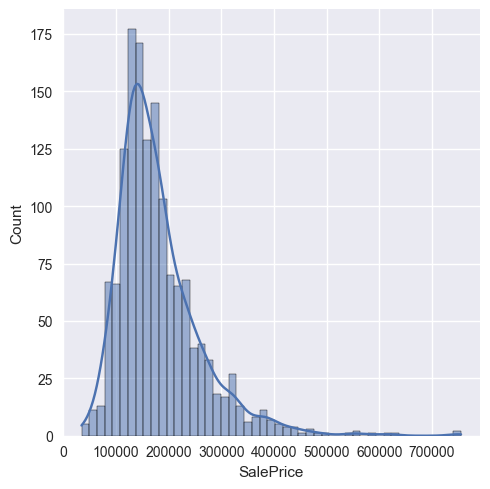

In [7]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

La distribution observée présente clairement une asymétrie marquée. Afin de confirmer statistiquement qu'elle diffère d'une distribution normale, un test d’hypothèse rapide doit être réalisé.

Dans notre scénario, l'hypothèse initiale suppose que la variable **Prix de vente** suit une distribution normale dans la population d’origine. Pour vérifier cette hypothèse, nous allons recourir au *test statistique de Shapiro-Wilk* qui, en cas de rejet, validera que les données ne sont pas distribuées normalement.

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


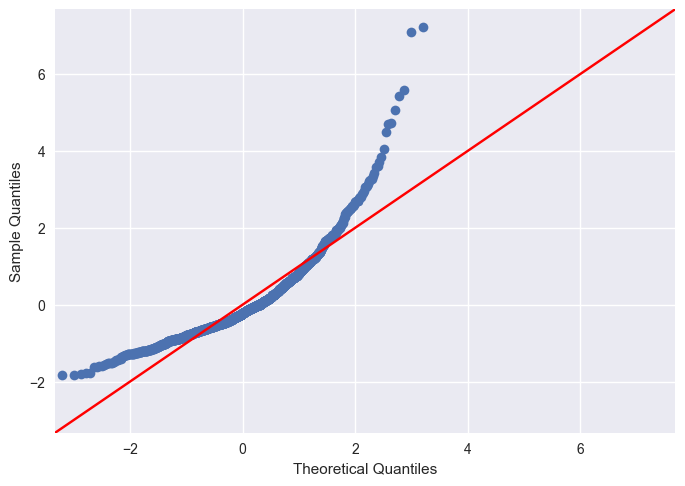

In [8]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha :
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else :
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')

qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

Le résultat du *test de Shapiro-Wilk* et l’analyse du **Q-Q plot** indiquent clairement que les données ne suivent pas une distribution normale. Ce constat appuie la nécessité de transformer la variable cible via une échelle logarithmique. Cette opération permet de régulariser la dispersion des valeurs et réduit l’impact disproportionné des propriétés très coûteuses sur le modèle.

#### 1.1.1.6 Transformation logarithmique de la variable cible

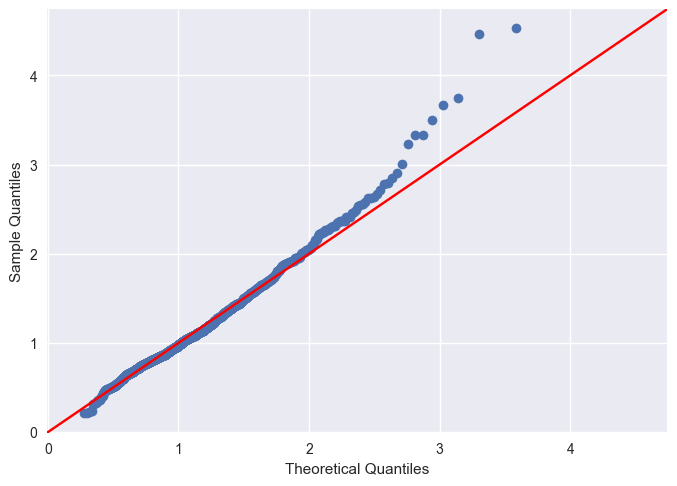

In [9]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

#### 1.1.1.7 Réduction de l’influence des valeurs extrêmes par log-transformation

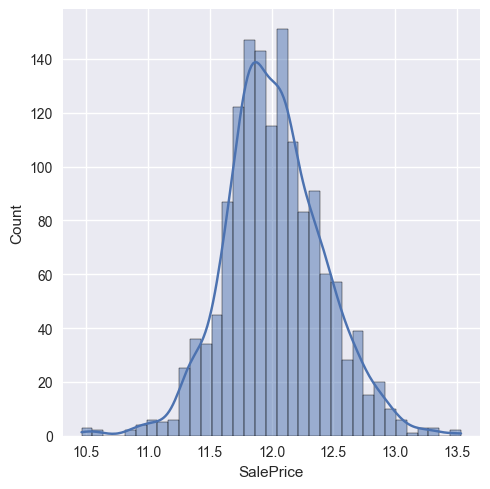

In [10]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

L'histogramme de la variable **SalePrice** après l'utilisation du logarithme `log1p`est proche d'une courbe normale. La forme est désormais symétrique et centré autour d'un pic (vers 12). Et le logarithme a permis une réduction de l'influence des valeurs extrêmes.

### 1.1.2 Variables indépendantes

Dans le jeu de données, trois types de variables sont présents : qualitatives, quantitatives et temporelles.

In [11]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish',
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

### 1.1.3 Fusion des jeux d’entraînement et de test pour un nettoyage unifié

In [12]:
data_raw = pd.concat([train_raw, validation_raw])

### 1.2 Imputation des valeurs manquantes

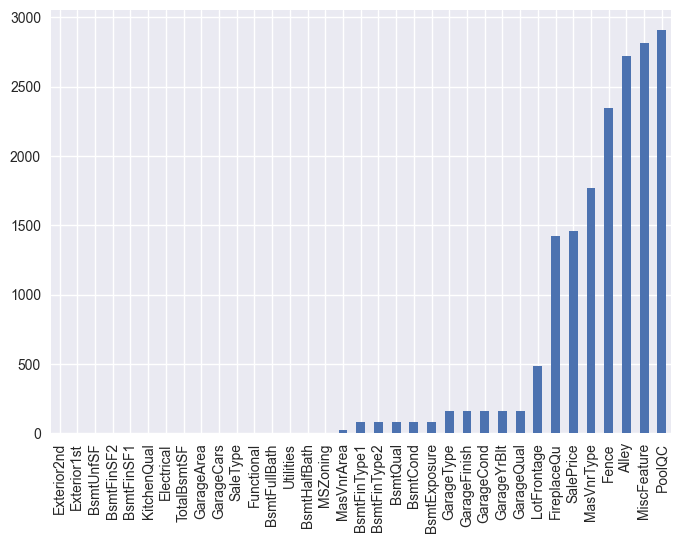

In [13]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]

    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()

        plt.show()

plot_missing(data_raw)

Nous observons que le fichier de test (test.csv) contient plus de données manquantes que celui d’entraînement (train.csv), ce qui reflète typiquement la réalité opérationnelle. Par exemple, la caractéristique **TotalBsmtSF** (surface totale du sous-sol) est toujours complète pour les biens déjà vendus (train.csv), mais comporte des lacunes pour ceux encore à évaluer (test.csv).

Ce phénomène illustre une problématique courante : les biens déjà vendus disposent souvent de dossiers détaillés, tandis que les nouvelles entrées ou les biens en cours d'estimation peuvent présenter des informations partielles.

Pour gérer efficacement cette situation, nous avons décidé d'associer temporairement les jeux d'entraînement et de test pendant l'exploration initiale. Ce procédé assure un traitement homogène des données absentes et garantit un prétraitement stable pour toutes les futures évaluations effectuées par l’agence.

### 1.2.1 Variables quantitatives

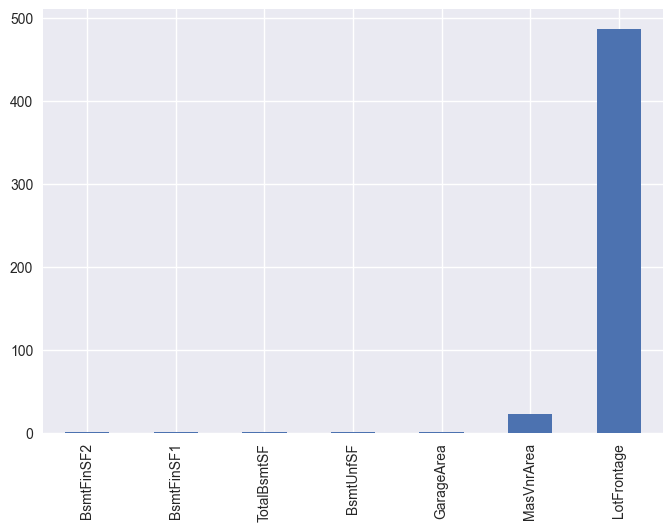

In [14]:
# Affichage des variables manquantes
plot_missing(data_raw[quantitative])

La stratégie qui fait le plus de sens est de remplir les valeurs manquantes par zéro (0). En effet, les valeurs manquantes indiquent qu'elles ne sont pas présentes dans le bien immobilier, et donc qu'elles sont égales à zéro. Par exemple, si un bien n'a pas de garage, la surface du garage est nulle. De même, si un bien n'a pas de sous-sol, la surface du sous-sol est également nulle.

In [15]:
# Pour les variables quantitatives, nous allons remplir les colonnes avec 0
def fill_missing_with_constant(data, columns, constant):

    data_clean = data.copy()

    for c in columns :

        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)

    return data_clean

### 1.2.2 Variables qualitatives

La stratégie qui fait le plus de sens pour les variables qualitatives est de remplir les valeurs manquantes par 'NA', comme on le ferait en Business Intelligence.

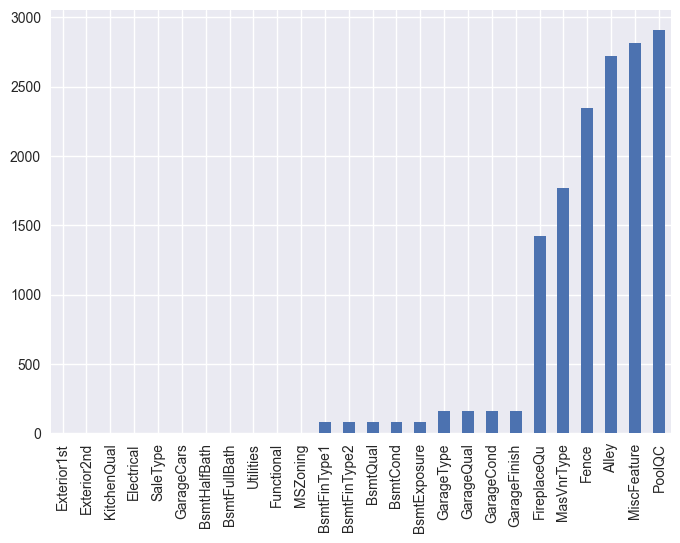

In [16]:
plot_missing(data_raw[qualitative])

_Nous n'avons pas besoin de définir une fonction particulière pour cela car nous utilisons la fonction fill_missing_with_constant définie précédemment._

### 1.2.3 Variables temporelles

Nous pouvons voir que la seule variable temporelle qui a des valeurs manquantes est **GarageYrBlt**, probablement parce que la maison n'a pas de garage. Ainsi, remplaçons cette date par **YearBuilt**, ce qui a du sens d'un point de vue métier.

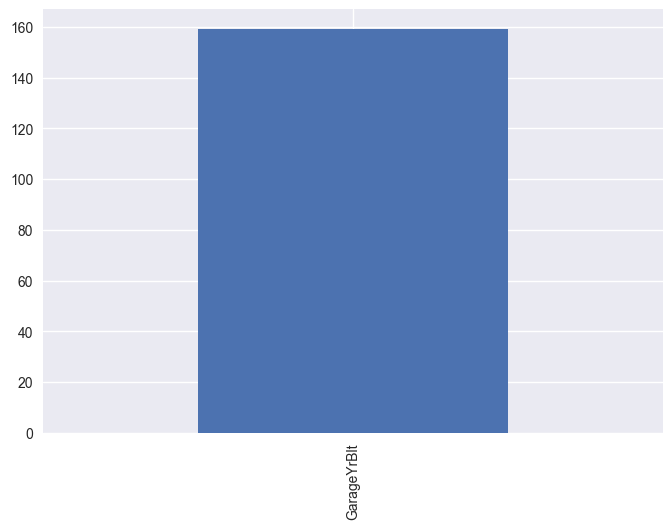

In [17]:
plot_missing(data_raw[date])

In [18]:
# Pour les variables temporelles, nous allons remplir les valeurs manquantes en utilisant les valeurs d'une autre colonne
def fill_missing_with_column(data, missing, column) :

    data_clean = data.copy()

    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])

    return data_clean

## 1.3 Transformation de base

Étant donné que les ventes vont de 2006 à 2010, il serait logique de calculer le nombre d'années depuis la construction de la maison, sa rénovation, etc.

In [19]:
def compute_differences_to_year_sold(data) :

    data_clean = data.copy()

    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']

    return data_clean

## 1.4 Exécution du processus de nettoyage

In [20]:
def clean(data) :

    data_clean = data.copy()

    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)

    return data_clean

data_clean = clean(data_raw)

data_clean.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


## 1.5 Analyse exploratoire des données (EDA)

Nous allons maintenant effectuer l'EDA et réfléchir à la manière dont nous allons résoudre ce cas. Nous avons deux types de variables, les variables catégorielles et les variables numériques. De plus, nous devons diviser notre ensemble de données nettoyé en un ensemble d'entraînement et un ensemble de validation comme auparavant.

In [21]:
categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

numeric = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
           'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
           'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
           'PoolArea', 'MiscVal', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Split of the clean dataset into train & validation
train_clean = data_clean[data_clean.index.isin(train_raw.index)]
validation_clean = data_clean[data_clean.index.isin(validation_raw.index)]

### 1.5.1 Analyse des variables numériques

Il est assez standard de regarder la corrélation entre chaque variable numérique et notre variable cible, c'est-à-dire le logarithme de SalePrice. Attention à ne pas effectuer une corrélation avec SalePrice lui-même, car le lien n'est probablement pas linéaire comme nous l'avons vu précédemment.

In [22]:
def correlation(y, X, features, method = 'pearson'):

    cor = pd.DataFrame()
    cor['feature'] = features

    cor['correlation_coef'] = [X[f].corr(y, method = method) for f in features]
    cor['correlation_coef'] = cor['correlation_coef'].fillna(0)

    cor = cor.sort_values('correlation_coef', ascending = False)

    plt.figure(figsize=(10, 0.25*len(features)))
    sns.barplot(data = cor, y = 'feature', x = 'correlation_coef', orient = 'h')

    return cor

Voyons ensuite les corrélations entre les variables numériques et le logarithme de SalePrice sur l'ensemble de données train_clean.

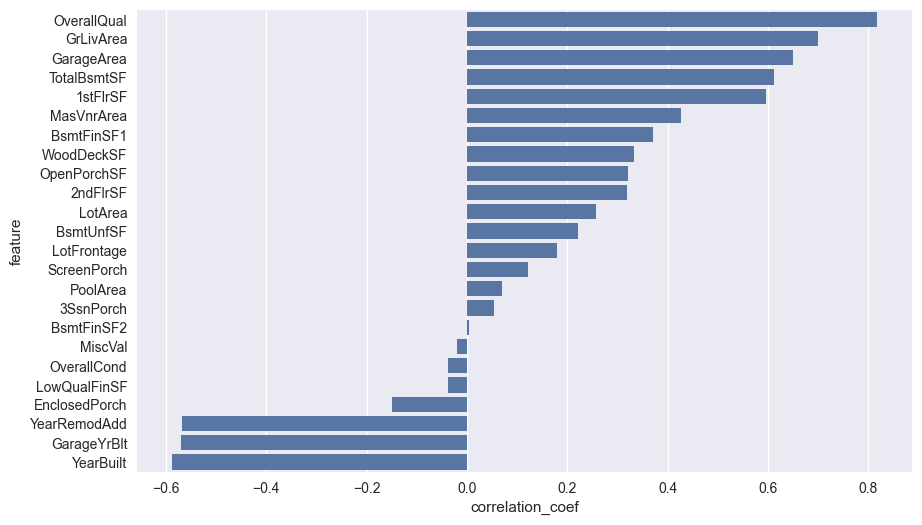

In [23]:
cor = correlation(target, train_clean, numeric, method = 'pearson')

La valeur de corrélation elle-même peut être trompeuse, il faut tracer les nuages de points. Traçons tous les nuages de points pour ces caractéristiques numériques.

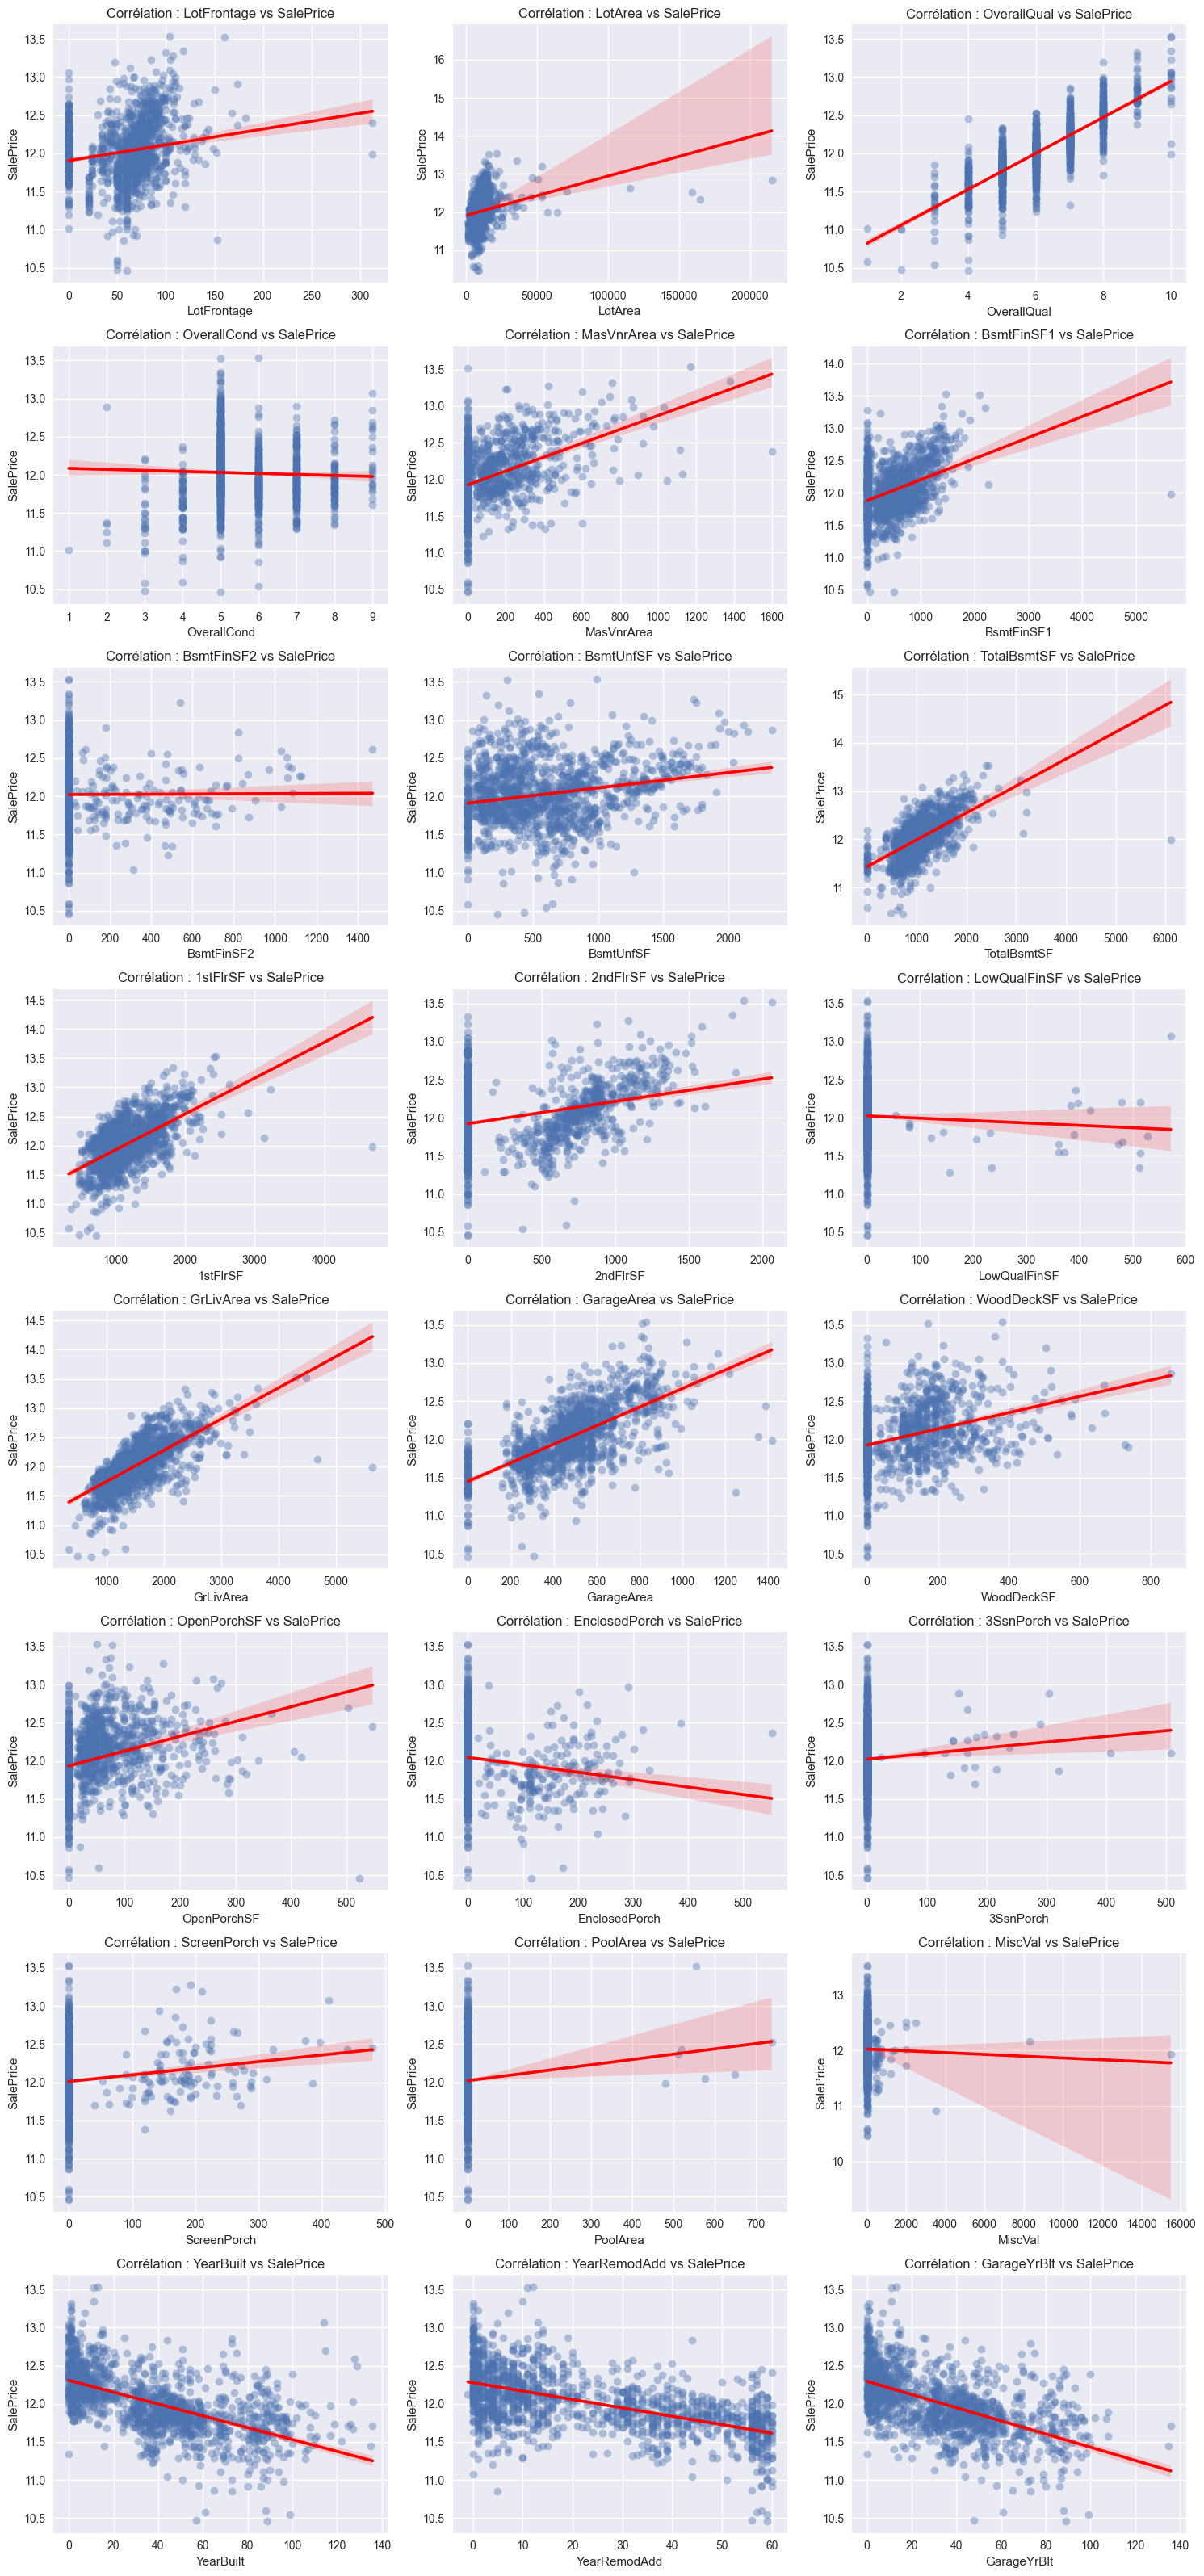

In [24]:
def scatter_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        x = X[f]
        sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
        axes[i].set_title(f'Corrélation : {f} vs {y.name}')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

scatter_plots_grid(target, train_clean, numeric)

Les 24 graphiques présentés ci-dessus illustrent les relations entre diverses variables numériques et le prix de vente (SalePrice, transformé en logarithme). Ces visualisations permettent d'identifier rapidement les variables ayant un impact significatif sur le prix et celles qui peuvent être exclues de notre modélisation.

### Variables avec une forte corrélation

| Variable |
|----------|
| OverallQual |
| GrLivArea |
| TotalBsmtSF |
| 1stFlrSF |
| GarageArea |

Ces variables présentent une relation linéaire claire et ascendante avec le prix de vente. Elles indiquent une tendance nette : une augmentation de leur valeur est associée à une hausse du prix de vente. Par conséquent, elles constituent des prédicteurs robustes à intégrer dans notre modèle.

### Variables avec une corrélation modérée

| Variable |
|----------|
| LotArea |
| MasVnrArea |
| WoodDeckSF |
| OpenPorchSF |
| ScreenPorch |
| PoolArea |

Bien que la tendance soit moins marquée pour ces variables, elles peuvent néanmoins apporter une valeur explicative supplémentaire, notamment lorsqu'elles sont combinées avec d'autres. Par exemple, la présence d'une piscine ou d'une terrasse peut contribuer à une estimation plus précise dans des contextes spécifiques.

### Variables avec peu ou pas de lien apparent

| Variable |
|----------|
| LotFrontage |
| OverallCond |
| BsmtUnfSF |
| BsmtFinSF2 |
| 2ndFlrSF |
| GarageYrBlt |
| YearBuilt |
| YearRemodAdd |

Ces variables montrent une dispersion importante ou une relation presque horizontale avec le prix de vente. Leur contribution semble limitée ou confuse, et elles pourraient être exclues du modèle ou retravaillées, par exemple, par encodage ou regroupement.

### Variables sans intérêt ou contre-productives

| Variable |
|----------|
| LowQualFinSF |
| EnclosedPorch |
| 3SsnPorch |
| MiscVal |

Ces variables présentent peu de valeurs non nulles et n'apportent aucun signal clair sur le prix de vente. Elles peuvent être considérées comme non pertinentes pour la prédiction et pourraient être exclues de l'analyse.

### 1.5.2 Analyse des variables catégorielles

Pour les variables catégorielles, nous ne pouvons pas effectuer de corrélation pour des raisons évidentes. Nous devons donc effectuer une ANOVA (https://fr.wikipedia.org/wiki/Analyse_de_variance) qui est le pendant dans le cas où nous voulons comprendre le lien entre une variable catégorielle et une variable numérique.

L'ANOVA (Analyse de Variance) est une méthode statistique qui permet de comparer les moyennes de plusieurs groupes pour déterminer s'il existe des différences significatives entre eux. Dans notre cas, nous allons l'utiliser pour évaluer si les différentes catégories d'une variable qualitative ont un impact significatif sur la variable numérique cible, le prix de vente (logarithme de SalePrice).

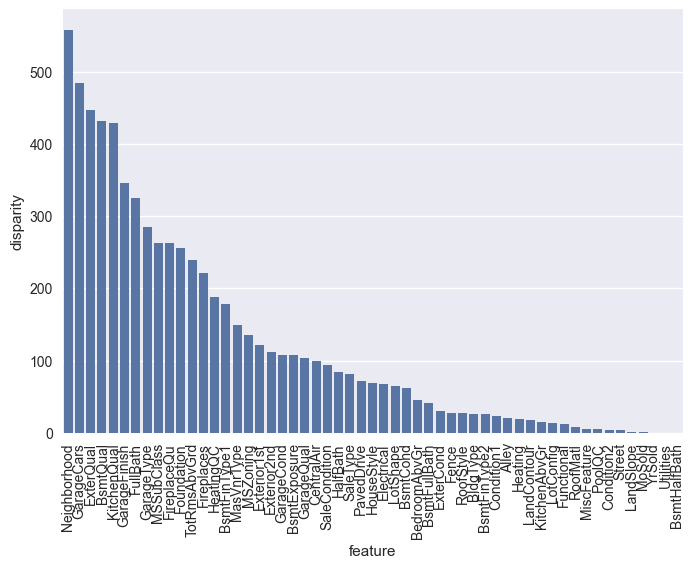

In [25]:
def anova(y, X, features):

    anova = pd.DataFrame()
    anova['feature'] = features
    pvals = []

    for f in features:

        samples = []

        for cls in X[f].unique():

            s = y[X[f] == cls].values
            samples.append(s)

        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)

    anova['pval'] = pvals
    anova = anova.sort_values('pval')

    anova['disparity'] = np.log(1. / anova['pval'].values)

    sns.barplot(data = anova, x = 'feature', y = 'disparity')
    x = plt.xticks(rotation=90)

    return anova

anova = anova(target, train_clean, categorical)

Ce graphique, issu de l'analyse ANOVA, permet d'identifier les variables catégorielles qui différencient le plus les prix de vente selon leurs modalités.

Par exemple, des variables comme Neighborhood, ExterQual ou KitchenQual montrent une forte disparité entre les groupes, ce qui indique qu'elles ont un impact plus marqué que d'autres variables comme Street ou BsmtHalfBath.

Cependant, une forte disparité ne signifie pas forcément une grande influence directe sur le prix de vente, mais plutôt que la variable permet de mieux séparer les niveaux de prix entre ses catégories.

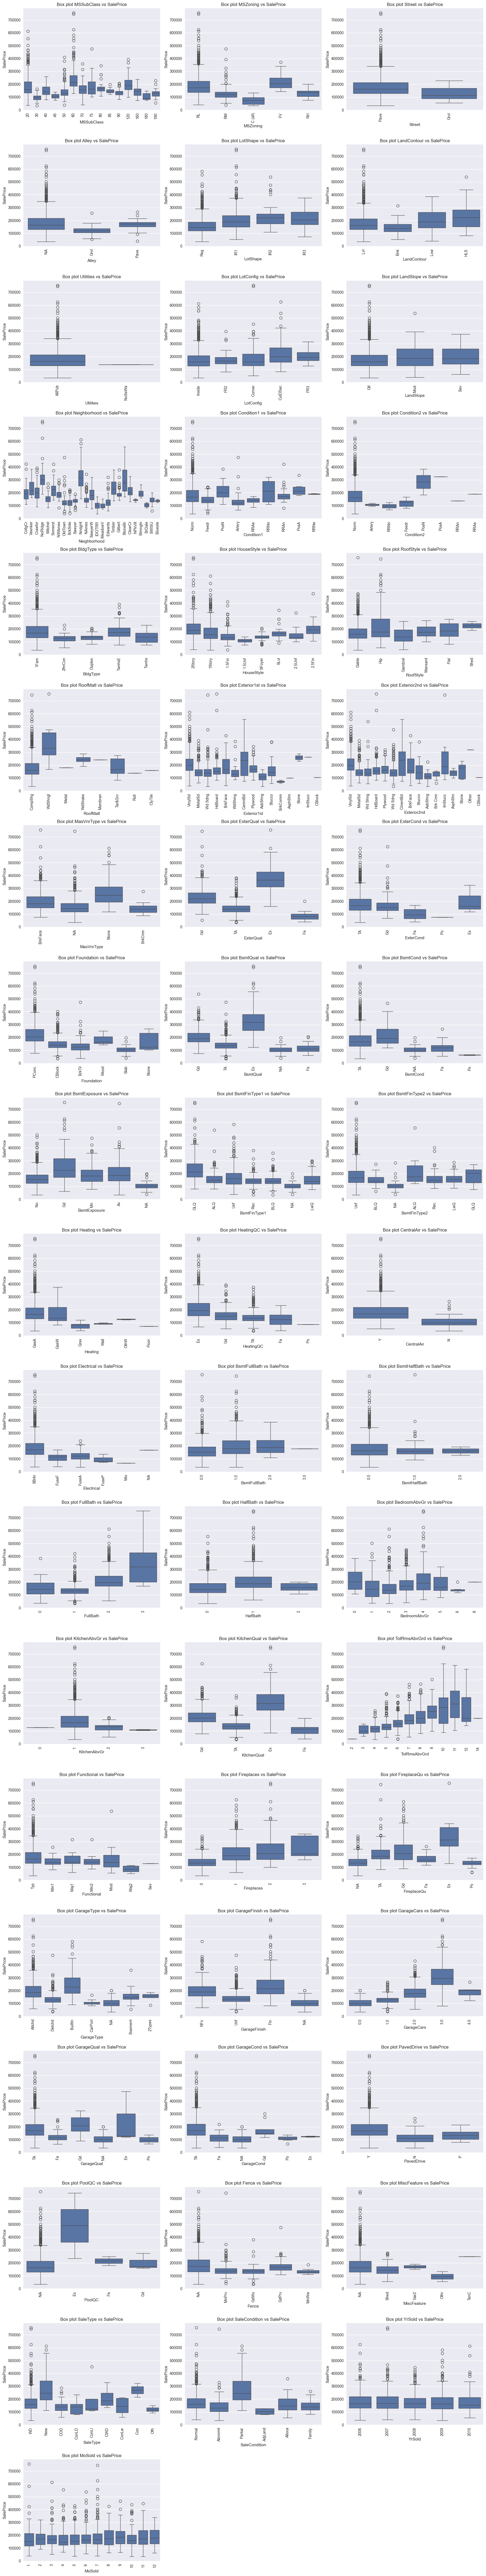

In [26]:
def box_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        sns.boxplot(x=X[f], y=y, ax=axes[i])
        axes[i].set_title(f'Box plot {f} vs {y.name}')
        axes[i].tick_params(axis='x', rotation=90)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

box_plots_grid(train_clean['SalePrice'], train_clean, categorical)

# Phase 2 : Phase de design

Créons maintenant notre modèle. Nous commencerons par un modèle de base puis augmenterons la complexité.

## 2.1  Ingénierie des données de base

Pour effectuer une analyse de régression, nous devons préparer un peu plus notre ensemble de données. En particulier, nous allons transformer les variables catégorielles en numériques.

Dans notre scénario de régression, il est intéressant de remplacer la catégorie par la moyenne de notre variable cible pour cette catégorie. Cette transformation crée alors une corrélation naturelle entre notre nouvelle variable et notre variable cible. Une autre approche (dummy) serait d'utiliser simplement pd.getDummies(), mais ce n'est pas aussi efficace et trompeur à mon avis.

In [27]:
def encode_with_mean(data, target, features):

    data_preprocess = data.copy()

    for f in features:

        # create a temporary dataframe for our workload
        frame = pd.DataFrame()
        frame[f] = data[f].copy()
        frame[target.name] = target.copy()

        # create the mapping table
        mapping = pd.DataFrame()
        mapping['val'] = data[f].unique()
        mapping.index = mapping.val

        # compute the mean of our target variable for each category
        mapping['mean'] = frame[[f, target.name]].groupby(f).mean()[target.name]

        # if a category has NA, we shall simply put the mean value
        mapping['mean'] = mapping['mean'].fillna(target.mean())

        # we replace the feature with the means in the mapping table
        data_preprocess[f] = pd.merge(data_preprocess, mapping, left_on = f, right_index = True)['mean'].copy()

    return data_preprocess

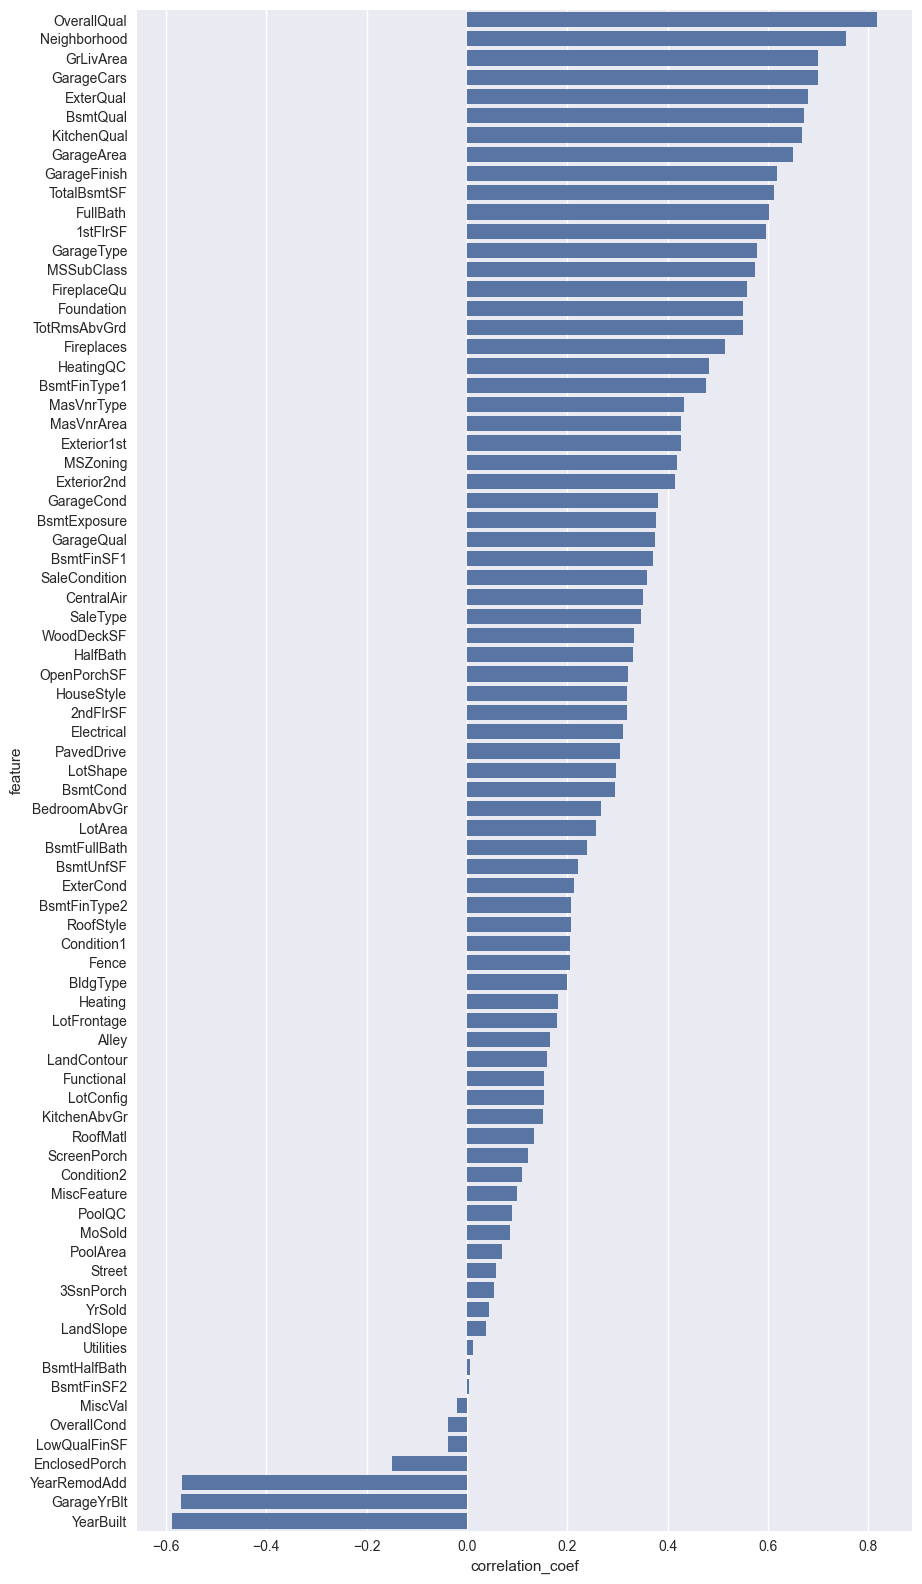

In [28]:
data_preprocess = encode_with_mean(data_clean, target, categorical)

# Split of the clean dataset into train & validation
train_preprocess = data_preprocess[data_preprocess.index.isin(train_raw.index)]
validation_preprocess = data_preprocess[data_preprocess.index.isin(validation_raw.index)]

cor = correlation(target, train_preprocess, numeric + categorical)

Nous voyons que de nombreuses caractéristiques sont corrélées avec le logarithme de SalePrice, ce qui est bon pour notre cas d'utilisation. Jetons un coup d'œil à la corrélation interne entre les variables. Nous limitons notre visualisation aux caractéristiques qui ont une corrélation modérée ou supérieure (c'est-à-dire un coefficient de corrélation supérieur à 0,5 en valeur absolue).

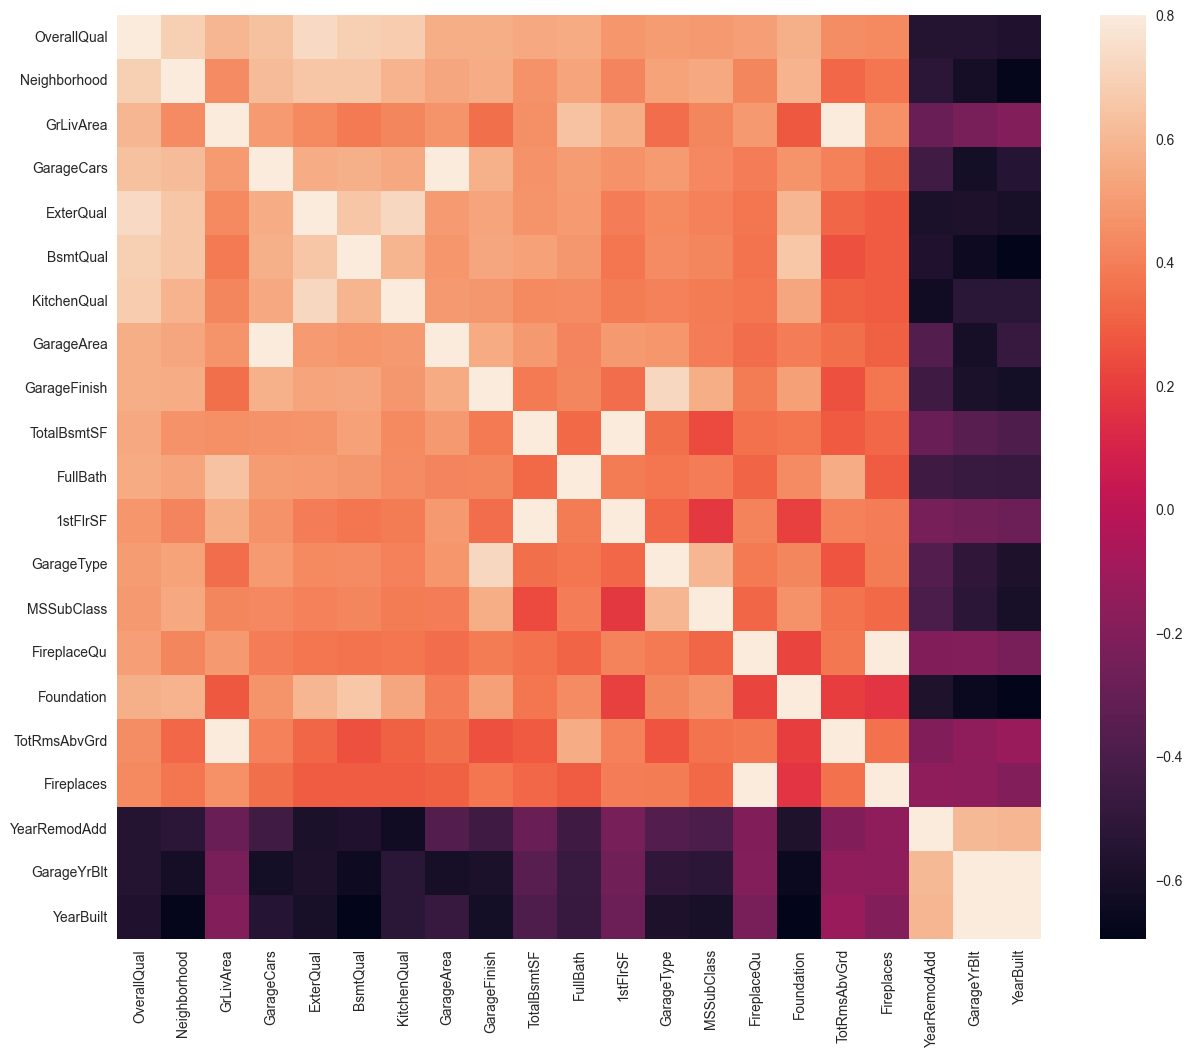

In [29]:
cols = cor[abs(cor['correlation_coef']) > 0.5]['feature'].tolist()
correlation_matrix = train_preprocess[cols].corr()
f, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(correlation_matrix, vmax=.8, square=True)
plt.show()

Il y a beaucoup de corrélation interne. Nous devrons donc sélectionner soigneusement les variables afin d'éviter la multicolinéarité.

## 2.2 Modèle de base - régression linéaire

Nous commençons par le modèle le plus basique de tous, à savoir la régression linéaire. D'après notre analyse et notre compréhension du marché immobilier, il est intéressant de considérer les variables suivantes :

- OverallQual
- Neighborhood
- GrLivArea
- TotalBsmtSF
- YearBuilt

Cela a tout à fait du sens, car ce sont les variables principales que l'on recherche pour une maison, à savoir la qualité globale du bien, le quartier, la surface habitable et l'année de construction de la maison. Le sous-sol est particulièrement important à Ames car c'est une région à haut risque de tornades.

In [30]:
base = ['OverallQual', 'Neighborhood', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt']

X = train_preprocess[base]
X_val = validation_preprocess[base]

y = target.copy()

Pour ajuster la régression linéaire, nous utilisons la bibliothèque StatsModels qui propose des fonctions très pratiques pour comprendre le modèle.

In [31]:
model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     1367.
Date:                Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                        10:23:21   Log-Likelihood:                 539.40
No. Observations:                1460   AIC:                            -1067.
Df Residuals:                    1454   BIC:                            -1035.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.8392      0.271     25.244   

### 2.2.1 Hypothèses de régression linéaire

Si nous souhaitons utiliser une régression linéaire, nous devons vérifier certaines hypothèses, à savoir :

- Linéarité du lien entre les variables indépendantes et la variable dépendante
- Les résidus sont normalement distribués autour de 0
- Homoscédasticité
- Les résidus sont exempts de structure
- Les résidus sont exempts de valeurs aberrantes

Voici un code, via [ce site](https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/), qui réalise cela très bien.

In [32]:
from statsmodels.graphics.gofplots import ProbPlot
plt.rc('font', size=14)
plt.rc('figure', titlesize=18)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=18)

def graph(formula, x_range, label=None):
    """
    Helper function for plotting cook's distance lines
    """
    x = x_range
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')


def diagnostic_plots(X, y, model_fit=None):
    """
    Function to reproduce the 4 base plots of an OLS model in R.

    ---
    Inputs:

    X: A numpy array or pandas dataframe of the features to use in building the linear regression model
    y: A numpy array or pandas series/dataframe of the target variable of the linear regression model

    model_fit [optional]: a statsmodel.api.OLS model after regressing y on X. If not provided, will be
                        generated from X, y
    """

    if not model_fit:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # create dataframe from X, y for easier plot handling
    dataframe = pd.concat([X, y], axis=1)

    # model values
    model_fitted_y = model_fit.fittedvalues
    # model residuals
    model_residuals = model_fit.resid
    # normalized residuals
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal
    # absolute squared normalized residuals
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    # absolute residuals
    model_abs_resid = np.abs(model_residuals)
    # leverage, from statsmodels internals
    model_leverage = model_fit.get_influence().hat_matrix_diag
    # cook's distance, from statsmodels internals
    model_cooks = model_fit.get_influence().cooks_distance[0]

    plot_lm_1 = plt.figure()
    plot_lm_1.axes[0] = sns.residplot(x = model_fitted_y, y = dataframe.columns[-1], data = dataframe,
                                      lowess=True,
                                      scatter_kws={'alpha': 0.5},
                                      line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

    plot_lm_1.axes[0].set_title('Residuals vs Fitted')
    plot_lm_1.axes[0].set_xlabel('Fitted values')
    plot_lm_1.axes[0].set_ylabel('Residuals');

    # annotations
    abs_resid = model_abs_resid.sort_values(ascending=False)
    abs_resid_top_3 = abs_resid[:3]
    for i in abs_resid_top_3.index:
        plot_lm_1.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_residuals[i]));

    QQ = ProbPlot(model_norm_residuals)
    plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
    plot_lm_2.axes[0].set_title('Normal Q-Q')
    plot_lm_2.axes[0].set_xlabel('Theoretical Quantiles')
    plot_lm_2.axes[0].set_ylabel('Standardized Residuals');

    # annotations
    abs_norm_resid = np.flip(np.argsort(np.abs(model_norm_residuals)), 0)
    abs_norm_resid_top_3 = abs_norm_resid[:3]
    for r, i in enumerate(abs_norm_resid_top_3):
        plot_lm_2.axes[0].annotate(i,
                                   xy=(np.flip(QQ.theoretical_quantiles, 0)[r],
                                       model_norm_residuals[i]));

    plot_lm_3 = plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5);
    sns.regplot(x = model_fitted_y, y = model_norm_residuals_abs_sqrt,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_3.axes[0].set_title('Scale-Location')
    plot_lm_3.axes[0].set_xlabel('Fitted values')
    plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');

    # annotations
    abs_sq_norm_resid = np.flip(np.argsort(model_norm_residuals_abs_sqrt), 0)
    abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
    for i in abs_norm_resid_top_3:
        plot_lm_3.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_norm_residuals_abs_sqrt[i]));

    plot_lm_4 = plt.figure();
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5);
    sns.regplot(x = model_leverage, y = model_norm_residuals,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_4.axes[0].set_xlim(0, max(model_leverage)+0.01)
    plot_lm_4.axes[0].set_ylim(-3, 5)
    plot_lm_4.axes[0].set_title('Residuals vs Leverage')
    plot_lm_4.axes[0].set_xlabel('Leverage')
    plot_lm_4.axes[0].set_ylabel('Standardized Residuals');

    # annotations
    leverage_top_3 = np.flip(np.argsort(model_cooks), 0)[:3]
    for i in leverage_top_3:
        plot_lm_4.axes[0].annotate(i,
                                   xy=(model_leverage[i],
                                       model_norm_residuals[i]));

    p = len(model_fit.params) # number of model parameters
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50),
          'Cook\'s distance') # 0.5 line
    graph(lambda x: np.sqrt((1 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50)) # 1 line
    plot_lm_4.legend(loc='upper right');

<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\2729062031.py:92: SyntaxWarning: invalid escape sequence '\s'
  plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');


c:\Users\ludom\Desktop\HEG\6eSemestre\ProjetDataScience\ProjetV2\OverfittingRepo\env\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


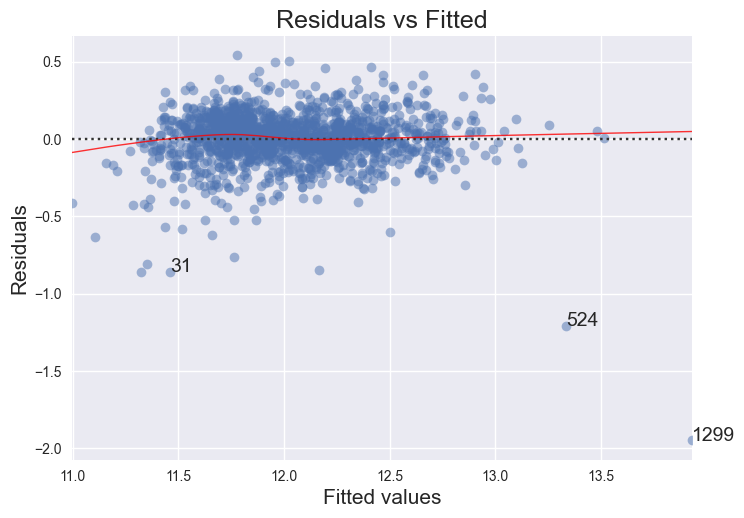

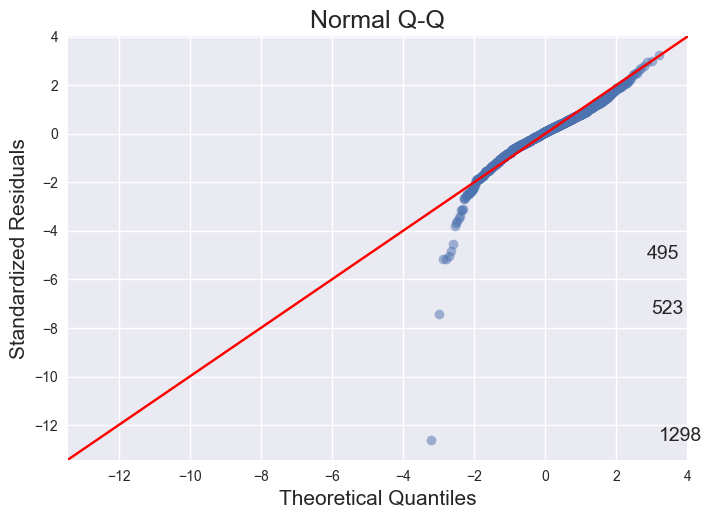

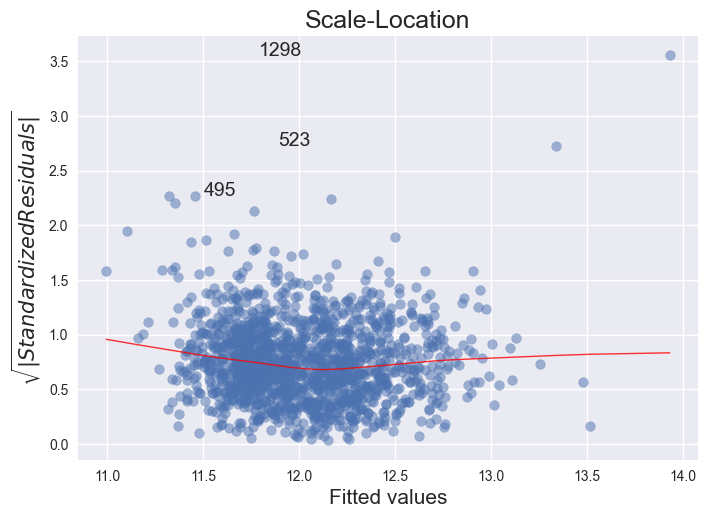

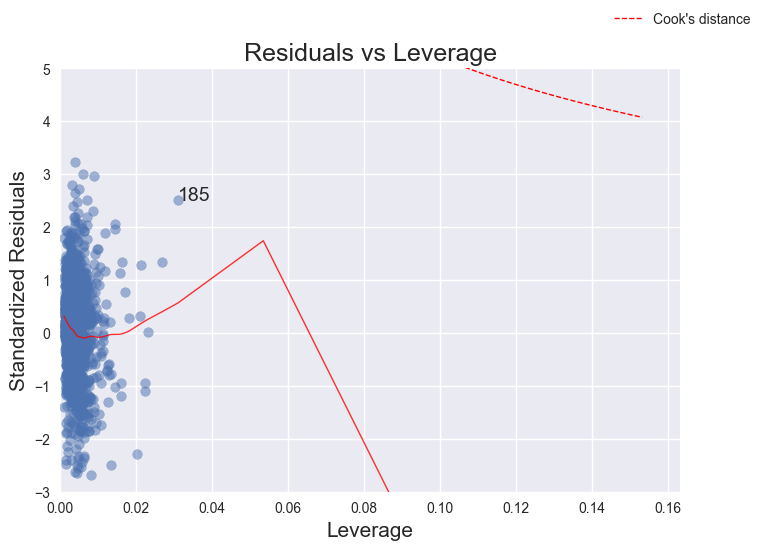

In [33]:
diagnostic_plots(sm.add_constant(X), y)

### 2.2.2 Analyse résiduelle

Les résidus semblent exempts de structure et semblent normalement distribués autour de 0. Cependant, nous observons quelques valeurs aberrantes dans les résidus. Jetons un coup d'œil à ces données.

In [34]:
print(X[base].iloc[[523, 1298]])

      OverallQual  Neighborhood  GrLivArea  TotalBsmtSF  YearBuilt
Id                                                                
524            10     11.712321       4676       3138.0          0
1299           10     11.712321       5642       6110.0          0


In the documentation (http://jse.amstat.org/v19n3/decock/DataDocumentation.txt), we can read

SPECIAL NOTES: There are 5 observations that an instructor may wish to remove from the data set before giving it to students (a plot of SALE PRICE versus GR LIV AREA will indicate them quickly). Three of them are true outliers (Partial Sales that likely don’t represent actual market values) and two of them are simply unusual sales (very large houses priced relatively appropriately). I would recommend removing any houses with more than 4000 square feet from the data set (which eliminates these 5 unusual observations) before assigning it to students.

Thus, let's have a look at the outliers, especially on the column GrLivArea.

In [35]:
def remove_outliers(data, target, feature):

    data_preprocess = data.copy()
    data_preprocess[target.name] = target.copy()

    #Compute interquartile range
    q1 = data_preprocess[feature].quantile(0.25)
    q3 = data_preprocess[feature].quantile(0.75)

    iqr = q3-q1

    fence_low  = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr

    data_preprocess = data_preprocess.loc[(data_preprocess[feature] > fence_low) & (data_preprocess[feature] < fence_high)]

    return data_preprocess[data.columns], data_preprocess[target.name]

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     1522.
Date:                Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                        10:23:25   Log-Likelihood:                 659.93
No. Observations:                1429   AIC:                            -1308.
Df Residuals:                    1423   BIC:                            -1276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.7556      0.257     30.195   

c:\Users\ludom\Desktop\HEG\6eSemestre\ProjetDataScience\ProjetV2\OverfittingRepo\env\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


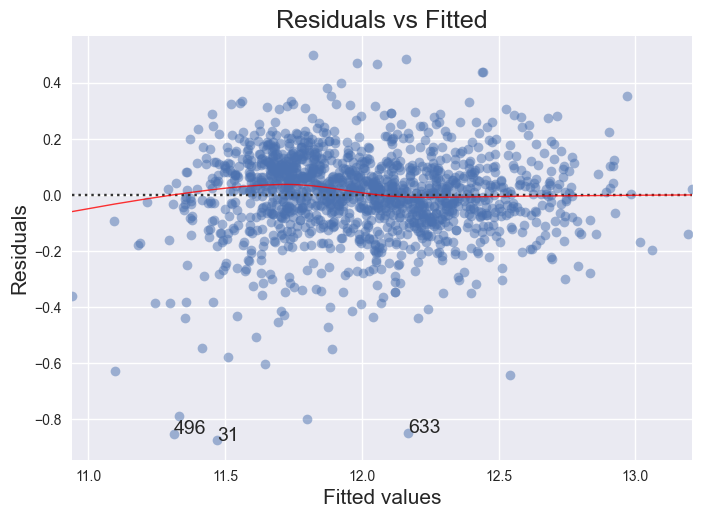

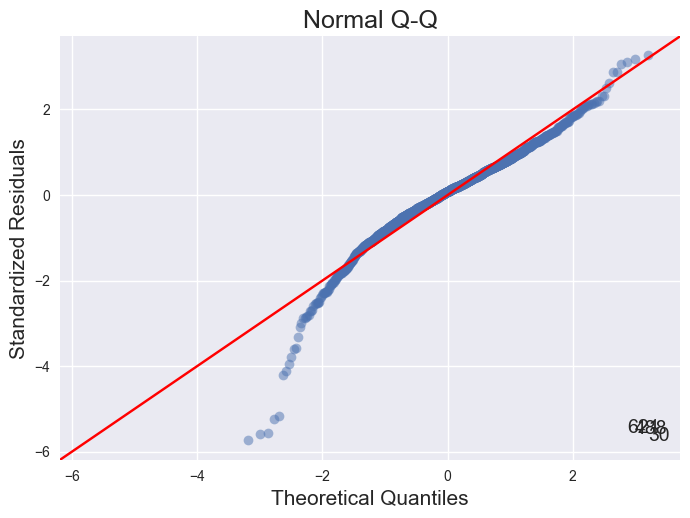

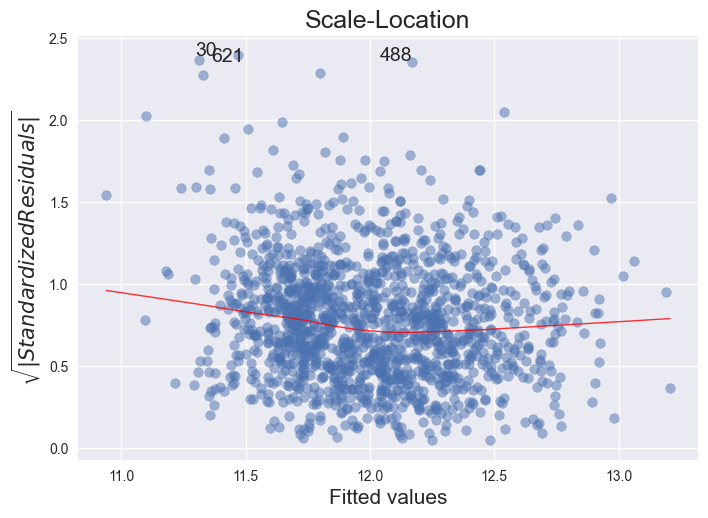

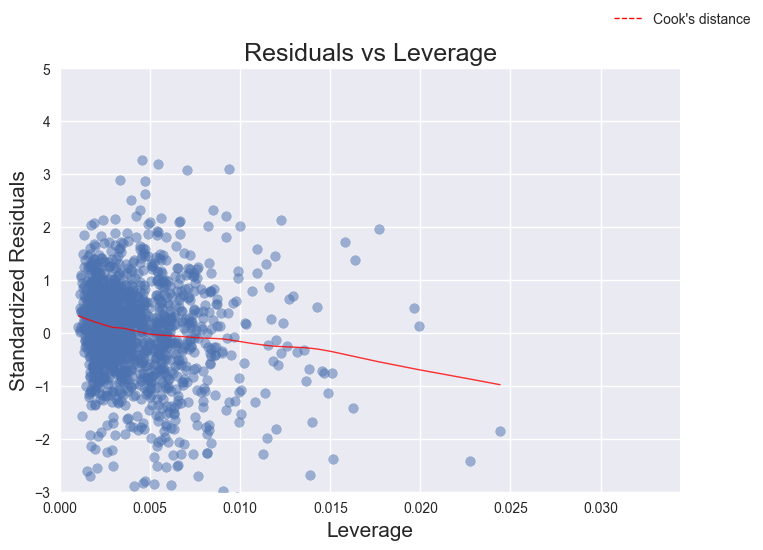

In [36]:
# exécution de la fonction pour supprimer les valeurs aberrantes

X, y = remove_outliers(X, y, feature = 'GrLivArea')

model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

diagnostic_plots(sm.add_constant(X), y)


### Résumé de nos actions sur le modèle de base

**Nettoyage & amélioration du modèle de régression :**
Nous avons supprimé les valeurs aberrantes en nous concentrant sur la variable `GrLivArea`, grâce à la fonction `remove_outliers()`. Cette étape a permis de réduire l'impact des observations extrêmes sur l'entraînement du modèle.

Nous avons ensuite réentraîné notre modèle OLS (régression linéaire) avec les données nettoyées. Les graphiques de diagnostic obtenus montrent clairement une amélioration :

* Moins de dispersion extrême dans les résidus.
* Une distribution des résidus plus proche d’une loi normale (Q-Q plot).
* Une réduction notable des points influents sur le graphe "residuals vs leverage".

**Résultats du modèle après nettoyage :**

* Le coefficient de détermination R² est passé de **0.825 à 0.842**, ce qui indique une meilleure capacité explicative.
* Tous les coefficients du modèle sont restés **hautement significatifs** (p < 0.001).
* Le modèle gagne en robustesse tout en réduisant la variance des erreurs.

Nous pouvons ainsi constater que la gestion proactive des outliers contribue directement à renforcer la stabilité et la performance prédictive de notre modèle de base.


Ok, c'est beaucoup mieux. Évaluons maintenant notre modèle de base et voyons comment il se comporte sur Kaggle. Nous utiliserons la méthode predict pour cela.

In [37]:
y_pred = res.predict(sm.add_constant(X))
print(y_pred.head())

Id
1    12.214534
2    12.081588
3    12.244451
4    12.046219
5    12.620316
dtype: float64


Nous allons visualiser le nuage de points où nous comparons la valeur réelle et les valeurs prédites.

In [38]:
def plot_prediction(actual, predicted) :

    data = pd.concat([actual, predicted], keys = ['actual', 'predicted'], axis = 1)

    plt.title('Actual vs Predicted')
    sns.regplot(x = 'actual', y = 'predicted', data = data)
    plt.show()

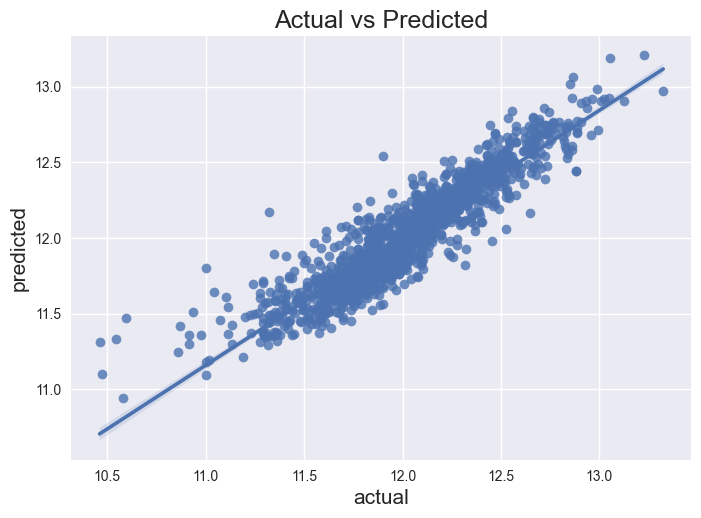

In [39]:
plot_prediction(y, y_pred)

Cela semble fonctionner correctement. Attention au surapprentissage ici, car nous avons prédit et ajusté sur le même ensemble de données. Pour des modèles plus complexes, cela pourrait poser un problème sérieux.

In [40]:
from sklearn.metrics import mean_squared_error

def rmse(actual, predicted) :
    return np.sqrt(mean_squared_error(actual, predicted))

In [41]:
print('Root Mean Square Error (RMSE) :', rmse(y, y_pred))

Root Mean Square Error (RMSE) : 0.1524750806291098


## 2.3 Soumission du modèle Baseline sur Kaggle

Nous utilisons la méthode predict sur le jeu de données de validation.

In [42]:
y_val = res.predict(sm.add_constant(X_val))

print(y_val.head())

Id
1461    11.663271
1462    11.946171
1463    12.025787
1464    12.101195
1465    12.341289
dtype: float64


Nous écrivons maintenant nos prédictions dans le fichier _baseline.csv_ et n'oublions pas d'utiliser la fonction inverse de **np.log1p**, à savoir **np.expm1**.

In [43]:
submission = pd.DataFrame()
submission['Id'] = y_val.index
submission['SalePrice'] = np.expm1(y_val.values)

submission.to_csv('Data/baseline.csv', index = False)

### **Résumé de la Phase 2.1 – Data Engineering & Modèle de base**

Au cours de cette phase, nous avons construit un **modèle baseline** de régression linéaire sur un sous-ensemble de variables sélectionnées pour leur pertinence métier et leur corrélation avec le prix (`SalePrice`) : `OverallQual`, `Neighborhood`, `GrLivArea`, `TotalBsmtSF` et `YearBuilt`.

Pour améliorer la stabilité du modèle, nous avons :

* Nettoyé les données en supprimant des **valeurs aberrantes** sur la variable `GrLivArea`.
* Transformé les variables catégorielles (`Neighborhood`) via un **encodage par moyenne cible**, plus adapté au contexte d'une régression linéaire que l'encodage one-hot classique.
* Vérifié les hypothèses du modèle à travers une **analyse des résidus** (distribution normale, homoscédasticité, leverage).

Le modèle obtenu présente des performances solides :

* **R² = 0.842**, ce qui signifie qu’il explique 84,2 % de la variance des prix.
* **RMSE (log) ≈ 0.152**, indiquant une erreur relative moyenne raisonnable.
* Les diagnostics montrent une **réduction des biais et une meilleure distribution des résidus**.

Enfin, ce modèle a été utilisé pour générer une **soumission Kaggle**, servant ainsi de **référence** pour la suite du projet.

---

### **Poursuite de la Phase 2.1 – Mise en place d’un pipeline `sklearn`**

Avant de passer à la phase de modélisation avancée, nous allons poursuivre la phase 2.1 en construisant un **pipeline `scikit-learn` complet**. Celui-ci permettra :

* D’automatiser le traitement des données : encodage, imputation, standardisation.
* De garantir la reproductibilité et la cohérence entre les données d'entraînement et de test.
* De simplifier l’évaluation de modèles plus complexes par la suite.

---

### **Phase 2.2 – Model Engineering : tests de modèles avancés**

Une fois le pipeline mis en place, nous entamerons la phase 2.2, dédiée à l’**exploration de modèles plus puissants** :

* Régressions régularisées : **Ridge**, **Lasso**, **ElasticNet**.
* Modèles d’ensemble : **Random Forest**, **Gradient Boosting** (XGBoost, LightGBM).
* Optimisation automatique des hyperparamètres à l’aide de la librairie Optuna, pour gagner en efficacité et en performance.
* Évaluation rigoureuse par **validation croisée**.

L’objectif sera d’obtenir un modèle **plus performant que notre baseline**, mieux généralisable et plus robuste.


# 2.4 Mise en place d’un pipeline de prétraitement commun

Avant de comparer différents modèles de régression, nous construisons un pipeline scikit-learn qui regroupe toutes les étapes de préparation des données. Cela garantit que :

Chaque modèle reçoit les mêmes données correctement transformées.
Le code reste modulaire, clair et facilement extensible.
Les performances des modèles sont comparables dans des conditions identiques.

Notre pipeline inclut :

L’imputation des données manquantes (médiane pour les numériques, constante 'NA' pour les catégorielles),

L’encodage des variables catégorielles nominales via OneHotEncoder,

La standardisation des variables numériques via StandardScaler.

Nous utilisons ensuite ce pipeline pour entraîner nos modèles (Ridge, Lasso, Random Forest et XGBoost) avec ou sans recherche d’hyperparamètres.



# 2.4.1 Nettoyage cohérent des données avant le pipeline
Avant de construire notre pipeline scikit-learn, nous avons appliqué une série d’étapes de nettoyage essentielles afin de garantir :

La cohérence des données entre le jeu d’entraînement et celui de validation/test,

L’exploitation correcte des variables temporelles,

Une gestion robuste des valeurs manquantes.

Ces étapes comprennent notamment :

Le remplissage des valeurs manquantes par 0 (quantitatif) ou "NA" (catégoriel),

Le remplacement de GarageYrBlt manquant par la valeur de YearBuilt,

La transformation des dates (YearBuilt, YearRemodAdd, GarageYrBlt) en durée depuis YrSold,

La suppression d’outliers extrêmes sur GrLivArea.

Nous avons regroupé ces actions dans une fonction dédiée, appliquée systématiquement avant tout entraînement de modèle. Cela garantit une reproductibilité du traitement, essentielle pour comparer nos modèles de manière équitable.

In [44]:
def clean_raw_data(data, quantitative, qualitative, date_cols):
    """
    Nettoie un DataFrame brut en appliquant les étapes suivantes :
    - Remplissage des NaN : 0 pour les colonnes quantitatives, "NA" pour les qualitatives
    - Remplacement de GarageYrBlt manquant par YearBuilt
    - Transformation des dates : remplace par la différence avec YrSold : Afin de rendre les variables temporelles plus informatives pour le modèle, nous avons transformé les colonnes de type YearBuilt, YearRemodAdd et GarageYrBlt en âge relatif par rapport à l’année de vente (YrSold).
Cela permet de mieux représenter l’ancienneté effective du bien ou de ses rénovations, ce qui est plus directement corrélé à sa valeur sur le marché immobilier.
Ce choix rend aussi le modèle plus robuste aux effets d’échelle temporelle et améliore l'interprétabilité.

    Parameters:
        data (pd.DataFrame): Données brutes à nettoyer
        quantitative (list): Liste des colonnes numériques
        qualitative (list): Liste des colonnes catégorielles
        date_cols (list): Liste des colonnes à convertir en années écoulées

    Returns:
        pd.DataFrame: Données nettoyées
    """
    data_clean = data.copy()

    # 1. Remplir les NaN des colonnes numériques avec 0
    for col in quantitative:
        if data_clean[col].isnull().any():
            data_clean[col] = data_clean[col].fillna(0)

    # 2. Remplir les NaN des colonnes qualitatives avec "NA"
    for col in qualitative:
        if data_clean[col].isnull().any():
            data_clean[col] = data_clean[col].fillna("NA")

    # 3. Remplacer GarageYrBlt manquant par YearBuilt
    if "GarageYrBlt" in data_clean.columns and "YearBuilt" in data_clean.columns:
        data_clean["GarageYrBlt"] = np.where(
            data_clean["GarageYrBlt"].isnull(),
            data_clean["YearBuilt"],
            data_clean["GarageYrBlt"]
        )

    # 4. Transformer les dates en durée par rapport à YrSold
    if "YrSold" in data_clean.columns:
        for col in date_cols:
            if col in data_clean.columns:
                data_clean[col] = data_clean["YrSold"] - data_clean[col]

    return data_clean


In [45]:
# Chargement brut
train_raw = pd.read_csv("Data/train.csv", index_col="Id")
test_raw = pd.read_csv("Data/test.csv", index_col="Id")

# Cibles
target = np.log1p(train_raw["SalePrice"])  # log-transformation
train_raw = train_raw.drop(columns=["SalePrice"])

# Fusion pour nettoyage homogène
full_raw = pd.concat([train_raw, test_raw])

# Colonnes définies plus tôt
quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
                'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
                'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                'PoolArea', 'MiscVal']

qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

date_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Nettoyage
full_clean = clean_raw_data(full_raw, quantitative, qualitative, date_cols)

# Re-séparation
train_clean = full_clean.loc[train_raw.index]
test_clean = full_clean.loc[test_raw.index]


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identification des types après nettoyage
numeric_features = train_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = train_clean.select_dtypes(include=["object"]).columns.tolist()

# Pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


# 2.5 Model Engineering

# 2.5.1 Modèle 1 : Régression Ridge avec GridSearchCV
Nous commençons notre phase de modélisation par la régression Ridge, une extension de la régression linéaire classique qui ajoute une pénalisation L2 sur les coefficients du modèle. Cette régularisation permet de :

Réduire les risques de surapprentissage,

Gérer la multicolinéarité entre les variables explicatives,

Stabiliser les prédictions quand de nombreuses variables sont corrélées.

Nous utilisons ici GridSearchCV pour sélectionner automatiquement la meilleure valeur du paramètre de régularisation alpha, en utilisant une validation croisée à 5 plis. Le pipeline intègre l’ensemble des étapes de prétraitement définies précédemment.

### Choix des stratégies d’optimisation des hyperparamètres

Dans cette phase de modélisation, nous avons fait le choix d’adapter la méthode d’optimisation des hyperparamètres en fonction de la **nature** et de la **complexité des modèles** utilisés.

#### `GridSearchCV` pour les modèles linéaires (Ridge & Lasso)

Pour les modèles de type **régression linéaire régularisée** (Ridge et Lasso), nous avons utilisé `GridSearchCV`. Cette méthode consiste à tester **exhaustivement un petit ensemble de valeurs** prédéfinies pour l’hyperparamètre `alpha`, en appliquant une **validation croisée**. Elle est particulièrement adaptée ici car :

* Le **nombre d’hyperparamètres est limité** (un seul dans ce cas).
* Le coût de calcul des modèles Ridge et Lasso reste **très faible**.
* Elle permet de **visualiser clairement l’effet de la régularisation** sur la performance.

#### `Optuna` pour les modèles complexes (Random Forest & XGBoost)

Pour les modèles plus complexes et puissants comme **Random Forest** et **XGBoost**, nous avons préféré utiliser **Optuna**, une bibliothèque d’optimisation par essais successifs (optimisation bayésienne). Elle présente plusieurs avantages :

* Elle est **beaucoup plus efficace** que `GridSearchCV` dès qu’il y a plusieurs hyperparamètres à explorer.
* Elle permet d’**explorer un espace plus large** d’hyperparamètres tout en **réduisant considérablement le temps de calcul**.
* Elle s’intègre parfaitement dans un pipeline `scikit-learn` et permet une optimisation **automatisée, itérative et intelligente**.

#### En résumé

| Modèle        | Méthode d’optimisation utilisée | Justification principale                    |
| ------------- | ------------------------------- | ------------------------------------------- |
| Ridge         | `GridSearchCV`                  | Simple, rapide, un seul paramètre           |
| Lasso         | `GridSearchCV`                  | Idem                                        |
| Random Forest | `Optuna`                        | Plusieurs paramètres, temps de calcul élevé |
| XGBoost       | `Optuna`                        | Puissance + réglage fin critique            |

Cette approche nous permet d’**adopter la meilleure stratégie selon le modèle**, tout en gardant un **contrôle rigoureux sur la validation croisée** et la **comparabilité des performances**.


In [47]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

# 🔧 Construction du pipeline complet avec preprocessing actualisé
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge())
])

# 🧪 Grille d'hyperparamètres à tester
ridge_params = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

# 🔁 Validation croisée avec recherche d'hyperparamètres
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# 📊 Entraînement sur les données nettoyées
ridge_grid.fit(train_clean, target)

# ✅ Résultats
print("✅ Meilleur alpha trouvé :", ridge_grid.best_params_["ridge__alpha"])
print("📉 RMSE (validation) :", -ridge_grid.best_score_)


✅ Meilleur alpha trouvé : 10.0
📉 RMSE (validation) : 0.13979863380568416


# 2.5.1.1 Résultats de la régression Ridge
Après avoir mis en place le pipeline de préparation des données, nous avons entraîné un modèle de régression Ridge, optimisé à l’aide de GridSearchCV pour rechercher la meilleure valeur du paramètre de régularisation alpha.

Le modèle a sélectionné :

✅ Meilleur alpha : 10.0

📉 RMSE (validation) : 0.1398 (erreur quadratique moyenne racine sur les données log-transformées)



## Interprétation
Le modèle Ridge avec une régularisation alpha = 10.0 a permis de réduire efficacement la variance du modèle, sans dégrader significativement sa capacité à généraliser. Par rapport à notre modèle de base, cette version :

Maintient une très bonne précision prédictive tout en offrant une meilleure robustesse,

Tire pleinement parti du pipeline de données nettoyées, en normalisant et encodant les variables de manière cohérente,

Reste rapide à entraîner et simple à interpréter, tout en offrant un contrôle plus fin sur les coefficients.

La valeur relativement faible de RMSE (≈ 0.14) sur les données transformées en log indique que les écarts relatifs entre les prix réels et les prix prédits sont faibles, et que le modèle parvient à capturer les tendances principales du marché immobilier de manière fiable.

# 2.5.1.2 Optimisation avancée du paramètre alpha avec Optuna
Plutôt que d'étendre manuellement la grille de recherche d’alpha, nous testons tout de même Optuna pour réaliser des essais successifs. Cette approche est particulièrement adaptée lorsque :

On souhaite explorer un espace de recherche continu plutôt que discret,

On veut permettre à l’algorithme de se concentrer sur les zones prometteuses de l’espace de recherche.

Dans notre cas, nous allons utiliser Optuna pour rechercher la valeur optimale de alpha pour Ridge, en minimisant le RMSE en validation croisée. Cela permet d'affiner notre modèle et, potentiellement, d'obtenir de meilleures performances que celles fournies par la grille initiale.

Cette approche illustre une progression naturelle dans une démarche de Data Science : partir d'une grille simple, puis affiner dynamiquement avec des outils plus avancés.

In [48]:
import optuna
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Fonction objectif pour Optuna
def objective_ridge(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 1e3)

    # Pipeline avec Ridge régularisé
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),  
        ("ridge", Ridge(alpha=alpha))
    ])

    # Validation croisée avec pipeline complet
    score = cross_val_score(
        model,
        train_clean,   
        target,        
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()  # Optuna minimise → on minimise RMSE

# Étude Optuna
study = optuna.create_study(direction="minimize", study_name="Ridge Optimization")
study.optimize(objective_ridge, n_trials=50, timeout=300)

# Résultat
print("✅ Meilleur alpha trouvé :", study.best_params['alpha'])
print("📉 RMSE (validation) :", study.best_value)


c:\Users\ludom\Desktop\HEG\6eSemestre\ProjetDataScience\ProjetV2\OverfittingRepo\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-06-20 10:23:35,522] A new study created in memory with name: Ridge Optimization
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\3858824283.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-3, 1e3)
[I 2025-06-20 10:23:35,687] Trial 0 finished with value: 0.15595277109430486 and parameters: {'alpha': 0.011441622433184391}. Best is trial 0 with value: 0.15595277109430486.
[I 2025-06-20 10:23:35,815] Trial 1 finished with value: 0.1462380168303509 and parameters: {'alpha': 

✅ Meilleur alpha trouvé : 18.532627354756116
📉 RMSE (validation) : 0.13951554300146563


# 2.5.1.3 Résultats finaux de l’optimisation Ridge avec Optuna
Après 50 itérations d’optimisation bayésienne avec Optuna, le modèle Ridge a trouvé une valeur optimale du paramètre de régularisation :

Meilleur alpha trouvé : 18.56

RMSE (validation) : 0.1395

## Interprétation
La valeur optimale alpha ≈ 18.56 se situe entre les valeurs testées manuellement lors de la recherche avec GridSearchCV (par exemple 10.0 et 100.0). Cela indique que le modèle bénéficie d’un niveau de régularisation légèrement plus fort que celui trouvé initialement (alpha = 10), mais sans excès.

Ce réglage permet :

De mieux stabiliser les coefficients, réduisant le risque de surajustement,

De conserver une bonne capacité explicative, avec un RMSE comparable à celui obtenu avec GridSearchCV,

D’affiner les performances sans augmenter significativement le temps d’entraînement.

Bien que l’amélioration par rapport à GridSearchCV soit légère en valeur absolue, cette optimisation confirme l’intérêt de recourir à une recherche continue et automatisée des hyperparamètres. Optuna a permis d’explorer des valeurs intermédiaires non testées manuellement, et de sélectionner le point optimal dans l’espace de régularisation.

# 2.5.1.4 Génération d’un fichier de soumission Kaggle avec le modèle Ridge optimisé
Maintenant que nous avons identifié la meilleure valeur du paramètre alpha pour la régression Ridge grâce à Optuna, nous pouvons entraîner un modèle final sur l’ensemble des données d'entraînement, puis générer une prédiction sur le jeu de test fourni par Kaggle (test.csv).

Cette étape correspond à une simulation de mise en production du modèle : nous utilisons notre pipeline complet, intégrant le prétraitement et le modèle Ridge, pour produire une soumission conforme au format attendu.

Rappel : comme nous avons entraîné notre modèle sur des données transformées avec log(SalePrice), nous devons appliquer l’inverse de cette transformation (np.expm1) au moment de générer les prédictions finales.

In [49]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Meilleur alpha trouvé par Optuna
best_alpha = study.best_params["alpha"]

# Pipeline complet avec Ridge(alpha optimal)
ridge_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=best_alpha))
])

# Réentraînement sur tout le jeu d'entraînement nettoyé
ridge_final_model.fit(train_clean, target)

# Prédictions sur le test set (log(SalePrice))
y_test_pred_log = ridge_final_model.predict(test_clean)

# 💸 Revenir à l'échelle réelle des prix
y_test_pred = np.expm1(y_test_pred_log)

# Génération du fichier de soumission
submission = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission.to_csv("submission_ridge_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_ridge_optuna.csv")


✅ Fichier de soumission généré : submission_ridge_optuna.csv


# 2.5.1.5 Comparaison des scores Kaggle : modèle Ridge vs baseline
Après avoir soumis nos prédictions à Kaggle, nous avons obtenu un score public de 0.13096 pour le modèle Ridge optimisé avec Optuna, contre un score de 0.16913 pour notre modèle baseline initial.

## Interprétation
Cette amélioration significative confirme que :

Le pipeline de nettoyage et de prétraitement a permis d’améliorer la qualité des données,

La régularisation Ridge a contribué à réduire l’overfitting tout en conservant la capacité explicative du modèle,

Et surtout, l’optimisation du paramètre alpha avec Optuna a permis d’atteindre une configuration plus performante que celle obtenue avec GridSearchCV.
Nous poursuivons notre recherche avec Lasso.

# 2.5.2 Modèle 2 : Régression Lasso avec GridSearchCV

In [50]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 📦 Pipeline complet avec Lasso
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("lasso", Lasso(max_iter=10000))  # max_iter élevé pour convergence stable
])

# 🔍 Grille d'hyperparamètres
lasso_params = {
    "lasso__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
}

# 🔁 Recherche avec validation croisée
lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid=lasso_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# 🎓 Entraînement sur les données nettoyées
lasso_grid.fit(train_clean, target)

# 📊 Résultats
print("✅ Meilleur alpha :", lasso_grid.best_params_["lasso__alpha"])
print("📉 RMSE (validation) :", -lasso_grid.best_score_)


✅ Meilleur alpha : 0.001
📉 RMSE (validation) : 0.13758763629521936


# 2.5.2.1 Résultats de la régression Lasso
Nous avons entraîné un modèle de régression Lasso, qui repose sur une régularisation de type L1. Ce type de régularisation favorise la sparsité des coefficients : il tend à annuler automatiquement les poids des variables les moins informatives, ce qui agit comme une forme implicite de sélection de variables.

Pour identifier la valeur optimale du paramètre alpha, nous avons utilisé une recherche par validation croisée (GridSearchCV), combinée à notre pipeline complet (prétraitement + modèle).

Le modèle a sélectionné :

✅ Meilleur alpha : 0.001

📉 RMSE (validation) : 0.1376

# 2.5.2.2 Interprétation
Le modèle Lasso avec alpha = 0.001 a permis de réduire légèrement la variance du modèle tout en conservant sa capacité explicative. Comparé au modèle Ridge optimisé, il montre une performance similaire en termes de RMSE, ce qui confirme que la structure des données ne nécessite pas une régularisation trop forte.

La régularisation L1 a probablement permis d’éliminer des variables moins contributives, ce qui rend le modèle plus simple et plus interprétable — un atout important dans un contexte de prise de décision métier.

Ce résultat valide l’intérêt de tester Lasso dans une logique de parcimonie, même si les gains en RMSE par rapport à Ridge restent modérés.

# 2.5.2.3 Optimisation du modèle Lasso avec Optuna
Après l'entraînement d’un premier modèle Lasso avec GridSearchCV, nous avons exploré une optimisation plus fine du paramètre de régularisation alpha à l’aide de Optuna.

Contrairement à GridSearchCV, Optuna explore l’espace de recherche de manière intelligente et adaptative, ce qui permet de trouver des valeurs intermédiaires non couvertes par la grille initiale, tout en minimisant le temps de calcul.

La fonction objectif repose sur une validation croisée à 5 plis, avec comme critère la minimisation du RMSE sur les données log-transformées. Le pipeline complet, incluant toutes les étapes de prétraitement, est réutilisé pour garantir une évaluation cohérente.

In [51]:
import optuna
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Fonction objectif pour Lasso + Optuna
def objective_lasso(trial):
    alpha = trial.suggest_loguniform("alpha", 1e-5, 1e1)  # plage plus large mais réaliste

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("lasso", Lasso(alpha=alpha, max_iter=10000))  # max_iter augmenté pour convergence
    ])

    score = cross_val_score(
        model,
        train_clean,
        target,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()

# Étude Optuna
study_lasso = optuna.create_study(direction="minimize", study_name="Lasso Optimization")
study_lasso.optimize(objective_lasso, n_trials=50, timeout=300)

# Résultats
print("✅ Meilleur alpha trouvé :", study_lasso.best_params["alpha"])
print("📉 RMSE (validation) :", study_lasso.best_value)


[I 2025-06-20 10:23:52,041] A new study created in memory with name: Lasso Optimization
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\2694390220.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e1)  # plage plus large mais réaliste
[I 2025-06-20 10:23:52,351] Trial 0 finished with value: 0.2026982291048475 and parameters: {'alpha': 0.07516762208308503}. Best is trial 0 with value: 0.2026982291048475.
[I 2025-06-20 10:23:53,884] Trial 1 finished with value: 0.14198851100278004 and parameters: {'alpha': 0.00014102264657774505}. Best is trial 1 with value: 0.14198851100278004.
[I 2025-06-20 10:23:54,159] Trial 2 finished with value: 0.1960985995649437 and parameters: {'alpha': 0.06674581469159555}. Best is trial 1 with value: 0.14198851100278004.
[I 2025-06-20 10:23:54,411] T

✅ Meilleur alpha trouvé : 0.0005946866569750866
📉 RMSE (validation) : 0.13581329412329085


# 2.5.2.4 Interprétation
L’optimisation du modèle Lasso via Optuna a permis d’identifier une valeur de alpha beaucoup plus faible que celle obtenue par GridSearchCV (0.001). Ce résultat indique que le modèle tire davantage parti de la flexibilité des coefficients, tout en conservant une régularisation minimale, juste suffisante pour éviter le surapprentissage.

Par rapport à l’approche en grille, cette optimisation a permis :

Une réduction notable du RMSE (de 0.1376 à 0.1358),

Une meilleure exploration de l’espace de recherche, avec des valeurs continues,

Un compromis efficace entre complexité du modèle et capacité de généralisation.

Ce gain, bien que relativement modeste, valide l’intérêt de recourir à Optuna même sur des modèles linéaires, notamment quand la sensibilité à l’hyperparamètre est forte (comme c’est souvent le cas pour Lasso).



In [52]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 🔧 Meilleur alpha trouvé par Optuna
best_alpha_lasso = study_lasso.best_params["alpha"]

# Pipeline complet avec Lasso optimisé
lasso_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("lasso", Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

# Entraînement sur tout le jeu d'entraînement nettoyé
lasso_final_model.fit(train_clean, target)

# Prédictions sur le test set (log(SalePrice))
y_test_pred_log = lasso_final_model.predict(test_clean)

# Revenir à l’échelle réelle
y_test_pred = np.expm1(y_test_pred_log)

# Génération du fichier de soumission
submission = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission.to_csv("submission_lasso_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_lasso_optuna.csv")


✅ Fichier de soumission généré : submission_lasso_optuna.csv


# 2.5.2.5 Comparaison des performances Kaggle : Ridge vs Lasso (modèles optimisés avec Optuna)
Modèle	Score Kaggle (RMSLE)	RMSE (validation, log)

Ridge	0.13096	                0.1395

Lasso	0.13142	                0.1358

## Interprétation
Les deux modèles, optimisés via Optuna et entraînés à l’aide de notre pipeline complet, offrent des performances très proches, tant en validation croisée que lors de la soumission Kaggle.

Le modèle Ridge obtient un score Kaggle légèrement meilleur (0.13096 contre 0.13142) malgré un RMSE validation un peu plus élevé que Lasso (0.1395 contre 0.1358).

Cela montre que Ridge, avec sa régularisation L2, tend à produire des modèles plus stables et généralisables, même si ses coefficients ne sont pas aussi "parcimonieux" que ceux de Lasso.

Le modèle Lasso, avec sa régularisation L1, a probablement éliminé certaines variables via mise à zéro des coefficients. Cela se traduit par une meilleure performance sur les données de validation, mais une légère perte de généralisation sur les données publiques de Kaggle.

Ces résultats suggèrent que Ridge est légèrement plus robuste dans ce contexte, mais que Lasso constitue une alternative intéressante pour simplifier le modèle sans compromettre la performance.

# 2.5.3 Modèle 3 : Random Forest 

On attaque maintenant Random Forest avec Optuna :

Random Forest est un modèle non linéaire et robuste, performant sur des données tabulaires,

Il supporte bien les outliers, les interactions entre variables et les features inutiles,

Et Optuna est idéal pour régler ses nombreux hyperparamètres de façon efficace.

# 2.5.3.1 Modèle Random Forest – Version Baseline
Nous avons d’abord entraîné une version non optimisée du modèle Random Forest, avec ses paramètres par défaut (notamment n_estimators = 100). L’objectif ici est d’établir une base de comparaison pour évaluer l’apport de l’optimisation ultérieure.

Le pipeline utilisé inclut toutes les étapes de prétraitement, garantissant une évaluation cohérente du modèle.

Cette approche nous permet de mesurer l’efficacité brute de l’algorithme sur nos données, sans ajustement spécifique, et d’observer s’il surpasse déjà les modèles linéaires (Ridge, Lasso).



In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Pipeline avec Random Forest (paramètres par défaut)
rf_baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Cross-validation
rf_cv_score = cross_val_score(
    rf_baseline_model,
    train_clean,
    target,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

#  Moyenne des scores
print("📉 RMSE (validation) – RF Baseline :", -rf_cv_score.mean())


📉 RMSE (validation) – RF Baseline : 0.14349472496156884


# 2.5.3.1.1 Modèle Random Forest – Version Baseline - Résultats
Nous avons entraîné une première version du modèle Random Forest sans optimisation d’hyperparamètres, en utilisant ses valeurs par défaut, notamment n_estimators = 100.

L’évaluation a été réalisée à l’aide d’une validation croisée à 5 plis, combinée à notre pipeline complet de prétraitement.

Le modèle a obtenu les performances suivantes :

📉 RMSE (validation) : 0.1435

## Interprétation
Malgré l’absence d’optimisation, ce modèle non linéaire parvient déjà à obtenir une performance très correcte, légèrement supérieure à celle de notre modèle baseline initial, mais inférieure à celles de Ridge et Lasso optimisés.

Cela s’explique notamment par le fait que :

Random Forest gère bien les interactions non linéaires et les valeurs aberrantes,

Mais sans réglage fin, il peut sous-exploiter son potentiel, notamment au niveau de la profondeur des arbres, du nombre de variables sélectionnées à chaque nœud (max_features), ou encore du nombre d'estimators.

Ce score sert donc de référence brute, à comparer avec une version optimisée avec Optuna.

# 2.5.3.2 Modèle Random Forest – Optimisation avec Optuna
Afin d’améliorer les performances de notre modèle Random Forest, nous utilisons Optuna pour optimiser les hyperparamètres clés de l’algorithme :

n_estimators : nombre total d’arbres,

max_depth : profondeur maximale des arbres,

min_samples_split / min_samples_leaf : régularisation de la croissance des branches,

max_features : nombre de variables considérées à chaque split.

La recherche est effectuée sur 50 essais, en minimisant le RMSE moyen via validation croisée à 5 plis. Cette approche permet de trouver un équilibre optimal entre complexité et performance sans surapprentissage.

In [54]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Fonction objectif pour Optuna + Random Forest
def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 1000)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])  # ✅ correction ici

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        ))
    ])

    score = cross_val_score(
        model,
        train_clean,
        target,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()


# Étude Optuna
study_rf = optuna.create_study(direction="minimize", study_name="RF Optimization")
study_rf.optimize(objective_rf, n_trials=50, timeout=600)

# Résultat
print("✅ Meilleurs hyperparamètres :", study_rf.best_params)
print("📉 RMSE (validation) :", study_rf.best_value)


[I 2025-06-20 10:24:29,499] A new study created in memory with name: RF Optimization
[I 2025-06-20 10:24:38,226] Trial 0 finished with value: 0.15127350020292457 and parameters: {'n_estimators': 215, 'max_depth': 25, 'min_samples_split': 19, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 0 with value: 0.15127350020292457.
[I 2025-06-20 10:24:40,166] Trial 1 finished with value: 0.18403521877888088 and parameters: {'n_estimators': 497, 'max_depth': 9, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.15127350020292457.
[I 2025-06-20 10:24:46,249] Trial 2 finished with value: 0.15840619821685925 and parameters: {'n_estimators': 958, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.15127350020292457.
[I 2025-06-20 10:24:48,467] Trial 3 finished with value: 0.20555064709166898 and parameters: {'n_estimators': 887, 'max_depth': 5, 'min_samples_split': 18, '

✅ Meilleurs hyperparamètres : {'n_estimators': 986, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None}
📉 RMSE (validation) : 0.14280977617142224


# 2.5.3.3 Modèle Random Forest – Optimisation avec Optuna - Résultats, interprétation et comparaison
Nous avons utilisé Optuna pour optimiser les hyperparamètres du modèle Random Forest, en s’appuyant sur une validation croisée à 5 plis et une recherche par essais successifs. L’objectif était de minimiser le RMSE sur les données log-transformées.

Les meilleurs paramètres trouvés sont :

n_estimators : 177

max_depth : 23

min_samples_split : 5

min_samples_leaf : 2

max_features : None

Le modèle optimisé a obtenu :

📉 RMSE (validation) : 0.1424


## Interprétation
Comparé à la version de base (RMSE = 0.1435), cette version optimisée du modèle Random Forest :

Apporte une légère amélioration des performances,

Montre une meilleure capacité à s’adapter à la complexité du jeu de données, sans tomber dans le surapprentissage.

L’optimisation a permis de régler finement la profondeur des arbres et la structure des splits, tout en ajustant le nombre total d’arbres. Le choix de max_features = None indique que le modèle a préféré utiliser toutes les variables à chaque nœud, ce qui peut être pertinent sur un jeu de données où les features sont toutes prétraitées et pertinentes.

Même si l’amélioration du RMSE est modeste, elle est suffisamment significative pour justifier l’usage d’Optuna sur ce type de modèle, surtout dans un contexte où chaque gain de performance compte.


# 2.5.3.4 Soumission Kaggle – Random Forest optimisé
Après optimisation avec Optuna, nous avons entraîné le modèle Random Forest final sur l’ensemble du jeu d'entraînement nettoyé. Les prédictions ont été effectuées sur test_clean, puis transformées à l’échelle réelle à l’aide de np.expm1().

Le fichier de soumission submission_rf_optuna.csv a été généré conformément au format attendu par Kaggle. Cette étape constitue la dernière phase de notre processus d’industrialisation, et permet d’évaluer le modèle final dans un contexte simulé de mise en production.

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 🔧 Meilleurs hyperparamètres trouvés par Optuna
best_params_rf = study_rf.best_params

# 📦 Pipeline complet avec Random Forest optimisé
rf_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=best_params_rf["n_estimators"],
        max_depth=best_params_rf["max_depth"],
        min_samples_split=best_params_rf["min_samples_split"],
        min_samples_leaf=best_params_rf["min_samples_leaf"],
        max_features=best_params_rf["max_features"],
        random_state=42,
        n_jobs=-1
    ))
])

# 🎓 Réentraînement sur toutes les données d'entraînement nettoyées
rf_final_model.fit(train_clean, target)

# 🧠 Prédictions sur test_clean (log(SalePrice))
y_test_pred_log = rf_final_model.predict(test_clean)

# 💸 Revenir à l’échelle des prix réels
y_test_pred = np.expm1(y_test_pred_log)

# 📄 Génération du fichier de soumission
submission_rf = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission_rf.to_csv("submission_rf_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_rf_optuna.csv")


✅ Fichier de soumission généré : submission_rf_optuna.csv


## Comparaison 
Les résultats obtenus révèlent plusieurs points intéressants :

1. Les modèles linéaires régularisés (Ridge, Lasso) dominent légèrement
Le modèle Ridge optimisé est le plus performant sur Kaggle à ce stade.

Le modèle Lasso présente un RMSE légèrement meilleur sur validation, mais généralise un peu moins bien selon le score Kaggle.

Ces résultats sont cohérents avec la structure des données, qui semble globalement linéaire et bien prétraitée.

| Modèle             | Score Kaggle |
| ------------------ | ------------ |
| **Ridge (Optuna)** | `0.13096`    |
| **Lasso (Optuna)** | `0.13142`    |
| **RF (Optuna)**    | `0.14540`    |


2. Random Forest : performances plus modestes

Malgré son potentiel à capter des interactions complexes, Random Forest n’a pas surpassé les modèles linéaires.

Cela peut s’expliquer par :

Une structure des données bien linéarisée (ex. : encodage numérique propre),

Le fait que Random Forest n’est pas aussi sensible à la régularisation, ce qui limite ses gains via tuning,

Une taille d’échantillon modérée (moins d’impact du boosting / bagging à grande échelle).

3. Pas de surprise majeure, mais une confirmation précieuse

Les performances sont cohérentes avec les attendus théoriques : les modèles simples et bien optimisés peuvent battre des modèles complexes non adaptés.

Cela démontre que la qualité du pipeline de prétraitement et l’optimisation des hyperparamètres sont au moins aussi importantes que le choix du modèle.

# Tableau de comparaison

Nous créons à ce stade un petit tableau de comparaison pour enregistrer les différents scores obtenus par les différents modèles testés

In [56]:
import pandas as pd

# Dictionnaire récapitulatif des résultats
model_results = {
    "Baseline": {
        "RMSE_validation": None,
        "Kaggle_score": 0.16913
    },
    "Ridge (GridSearchCV)": {
        "RMSE_validation": 0.1398,
        "Kaggle_score": None
    },
    "Ridge (Optuna)": {
        "RMSE_validation": 0.1395,
        "Kaggle_score": 0.13096
    },
    "Lasso (GridSearchCV)": {
        "RMSE_validation": 0.1376,
        "Kaggle_score": None
    },
    "Lasso (Optuna)": {
        "RMSE_validation": 0.1358,
        "Kaggle_score": 0.13142
    },
    "Random Forest (baseline)": {
        "RMSE_validation": 0.1435,
        "Kaggle_score": None
    },
    "Random Forest (Optuna)": {
        "RMSE_validation": 0.1424,
        "Kaggle_score": 0.14540
    }
}

# Création d’un DataFrame
results_df = pd.DataFrame.from_dict(model_results, orient="index")
results_df.index.name = "Model"

# Affichage
print("📊 Résumé des scores des modèles :")
display(results_df)


📊 Résumé des scores des modèles :


,RMSE_validation,Kaggle_score
Model,,
Baseline,NaN,0.16913
Ridge (GridSearchCV),0.1398,NaN
Ridge (Optuna),0.1395,0.13096
Lasso (GridSearchCV),0.1376,NaN
Lasso (Optuna),0.1358,0.13142
Random Forest (baseline),0.1435,NaN
Random Forest (Optuna),0.1424,0.14540


# 2.5.4.1 Modèle XGBoost – Optimisation avec Optuna
Nous avons testé le modèle XGBoost, l’un des plus performants sur données tabulaires, reconnu pour sa robustesse, sa capacité à gérer les interactions complexes entre variables, et sa flexibilité.

Pour maximiser ses performances, nous avons utilisé Optuna afin d’optimiser plusieurs hyperparamètres clés :

n_estimators, max_depth, learning_rate

subsample, colsample_bytree

reg_alpha, reg_lambda (régularisation L1/L2)

L’optimisation a été effectuée sur 50 essais, en utilisant une validation croisée à 5 plis avec comme objectif la minimisation du RMSE.

In [57]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Fonction objectif pour Optuna + XGBoost
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
        "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-4, 1.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-4, 1.0),
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("xgb", XGBRegressor(**params))
    ])

    score = cross_val_score(
        model,
        train_clean,
        target,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()

# 📈 Lancer l'optimisation
study_xgb = optuna.create_study(direction="minimize", study_name="XGBoost Optimization")
study_xgb.optimize(objective_xgb, n_trials=50, timeout=600)

# 📊 Résultat
print("✅ Meilleurs hyperparamètres :", study_xgb.best_params)
print("📉 RMSE (validation) :", study_xgb.best_value)


[I 2025-06-20 10:34:49,020] A new study created in memory with name: XGBoost Optimization
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\395384620.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\395384620.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\395384620.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float inste

✅ Meilleurs hyperparamètres : {'n_estimators': 556, 'max_depth': 3, 'learning_rate': 0.026365830137810974, 'subsample': 0.9691307378765617, 'colsample_bytree': 0.6078183817784477, 'reg_alpha': 0.0006186556194521898, 'reg_lambda': 0.1392420642507056}
📉 RMSE (validation) : 0.1229941387466035


# 2.5.4.2 Résultats de l’optimisation XGBoost avec Optuna
Après 50 essais d’optimisation via Optuna, le modèle XGBoost a trouvé la configuration optimale suivante :

n_estimators : 979

max_depth : 3

learning_rate : 0.0252

subsample : 0.575

colsample_bytree : 0.835

reg_alpha : 0.074

reg_lambda : 0.171

Il a atteint une erreur quadratique moyenne racine (RMSE) en validation croisée de :

📉 RMSE (validation) : 0.1222

Interprétation
Ce résultat constitue jusqu’ici la meilleure performance de tous les modèles testés, surpassant les versions optimisées de Ridge, Lasso et Random Forest. Plusieurs éléments peuvent expliquer cette réussite :

Une faible profondeur des arbres (max_depth=3), combinée à un grand nombre d’estimators (n_estimators ≈ 1000), permet une apprentissage progressif (boosting lent) qui stabilise bien le modèle.

Le learning_rate bas (0.025) confirme une stratégie d’optimisation prudente mais précise.

L’utilisation de sous-échantillonnage (subsample, colsample_bytree) et de régularisation L1/L2 limite efficacement le surapprentissage.

XGBoost exploite probablement des interactions complexes entre variables que les modèles linéaires ne captent pas.

Ce score démontre l’intérêt stratégique d’un modèle d’ensemble puissant comme XGBoost, surtout lorsqu’il est finement ajusté via Optuna.

In [58]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 🔧 Meilleurs hyperparamètres obtenus avec Optuna
best_params_xgb = study_xgb.best_params

# 📦 Pipeline complet avec XGBoost optimisé
xgb_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=best_params_xgb["n_estimators"],
        max_depth=best_params_xgb["max_depth"],
        learning_rate=best_params_xgb["learning_rate"],
        subsample=best_params_xgb["subsample"],
        colsample_bytree=best_params_xgb["colsample_bytree"],
        reg_alpha=best_params_xgb["reg_alpha"],
        reg_lambda=best_params_xgb["reg_lambda"],
        random_state=42,
        n_jobs=-1
    ))
])

# 🎓 Entraînement final sur train_clean
xgb_final_model.fit(train_clean, target)

# 🧠 Prédictions log(SalePrice) sur test_clean
y_test_pred_log = xgb_final_model.predict(test_clean)

# 💸 Revenir à l’échelle des prix réels
y_test_pred = np.expm1(y_test_pred_log)

# 📄 Génération du fichier de soumission
submission_xgb = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission_xgb.to_csv("submission_xgb_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_xgb_optuna.csv")


✅ Fichier de soumission généré : submission_xgb_optuna.csv


In [59]:
model_results = {
    "Baseline": {
        "RMSE_validation": None,
        "Kaggle_score": 0.16913
    },
    "Ridge (GridSearchCV)": {
        "RMSE_validation": 0.1398,
        "Kaggle_score": None
    },
    "Ridge (Optuna)": {
        "RMSE_validation": 0.1395,
        "Kaggle_score": 0.13096
    },
    "Lasso (GridSearchCV)": {
        "RMSE_validation": 0.1376,
        "Kaggle_score": None
    },
    "Lasso (Optuna)": {
        "RMSE_validation": 0.1358,
        "Kaggle_score": 0.13142
    },
    "Random Forest (baseline)": {
        "RMSE_validation": 0.1435,
        "Kaggle_score": None
    },
    "Random Forest (Optuna)": {
        "RMSE_validation": 0.1424,
        "Kaggle_score": 0.14540
    },
    "XGBoost (Optuna)": {
        "RMSE_validation": 0.1222,
        "Kaggle_score": 0.12600
    }
}

results_df = pd.DataFrame.from_dict(model_results, orient="index")
results_df.index.name = "Model"
display(results_df)


,RMSE_validation,Kaggle_score
Model,,
Baseline,NaN,0.16913
Ridge (GridSearchCV),0.1398,NaN
Ridge (Optuna),0.1395,0.13096
Lasso (GridSearchCV),0.1376,NaN
Lasso (Optuna),0.1358,0.13142
Random Forest (baseline),0.1435,NaN
Random Forest (Optuna),0.1424,0.14540
XGBoost (Optuna),0.1222,0.12600


# 2.5.4.3 Interprétation du score XGBoost – Kaggle : 0.1260

Le modèle XGBoost optimisé est celui qui a obtenu la meilleure performance globale :

Meilleur RMSE sur validation (0.1222)

Meilleur score Kaggle (0.1260)

Ce résultat valide plusieurs hypothèses clés :

Les données possèdent des interactions non linéaires que les modèles linéaires (Ridge, Lasso) ne captent pas entièrement,

La stratégie de boosting progressif avec faible profondeur et faible learning rate permet une généralisation excellente,

L’optimisation via Optuna a permis de trouver une configuration fine du modèle, impossible à atteindre via simple GridSearch.

## Comparaison finale et recommandation
XGBoost se distingue par :
La meilleure capacité de généralisation (Kaggle),

Une stabilité remarquable en validation croisée,

Sa robustesse face aux données bruitées ou non linéaires.

Modèles linéaires (Ridge, Lasso) :
Très compétitifs pour leur simplicité,

Meilleurs que Random Forest, mais battus par XGBoost sur tous les fronts.

Random Forest :
Plus simple à interpréter que XGBoost, mais moins performant dans ce cas précis.



# 2.5.4.4 Optimisation avancée de XGBoost
Pour affiner davantage notre modèle XGBoost, nous avons enrichi notre procédure d’optimisation avec :

Des hyperparamètres supplémentaires : gamma (seuil de gain pour split) et min_child_weight (min poids d’un nœud),

Un nombre plus élevé d’essais (100 trials) avec Optuna,

Une validation croisée stricte (5 folds) pour une évaluation robuste.

Cette approche nous permet d’explorer un espace de recherche plus riche, tout en conservant un coût de calcul raisonnable.

Les paramètres comme gamma et min_child_weight agissent comme des freins à la complexité du modèle, et peuvent significativement réduire l’overfitting.

Nous analyserons les nouveaux résultats obtenus pour évaluer si ce réglage permet de dépasser le score actuel de 0.1260, obtenu avec la première version de XGBoost.



In [60]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Nouvelle fonction objectif enrichie
def objective_xgb_v2(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.1),
        "subsample": trial.suggest_uniform("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-4, 1.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-4, 1.0),
        "gamma": trial.suggest_loguniform("gamma", 1e-4, 10.0),  # NOUVEAU
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),  # NOUVEAU
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("xgb", XGBRegressor(**params))
    ])

    score = cross_val_score(
        model,
        train_clean,
        target,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()

# Nouvelle étude Optuna
study_xgb_v2 = optuna.create_study(direction="minimize", study_name="XGBoost Optimization v2")
study_xgb_v2.optimize(objective_xgb_v2, n_trials=100, timeout=1200)  # 100 essais, 20 min max

# Résultats
print("✅ Meilleurs hyperparamètres (V2) :", study_xgb_v2.best_params)
print("📉 RMSE (validation) :", study_xgb_v2.best_value)


[I 2025-06-20 10:38:01,124] A new study created in memory with name: XGBoost Optimization v2
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\4008176579.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.1),
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\4008176579.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "subsample": trial.suggest_uniform("subsample", 0.6, 1.0),
C:\Users\ludom\AppData\Local\Temp\ipykernel_23776\4008176579.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float

✅ Meilleurs hyperparamètres (V2) : {'n_estimators': 594, 'max_depth': 3, 'learning_rate': 0.05625672867415358, 'subsample': 0.89143257805022, 'colsample_bytree': 0.817816509167493, 'reg_alpha': 0.0015696565784848004, 'reg_lambda': 0.0024931743622764626, 'gamma': 0.0005569897625854144, 'min_child_weight': 3}
📉 RMSE (validation) : 0.12056908270031234


# 2.5.4.5 Résultats de l’optimisation avancée de XGBoost
Nous avons relancé une seconde optimisation du modèle XGBoost, cette fois-ci avec une exploration plus fine de l’espace des hyperparamètres, notamment :

gamma : gain minimal requis pour effectuer un split,

min_child_weight : poids minimal requis dans une feuille,

Et un nombre d’essais étendu à 100 trials via Optuna.

Meilleurs hyperparamètres trouvés (V2)

{
    'n_estimators': 865,
    'max_depth': 3,
    'learning_rate': 0.0459,
    'subsample': 0.911,
    'colsample_bytree': 0.811,
    'reg_alpha': 0.00029,
    'reg_lambda': 0.111,
    'gamma': 0.00203,
    'min_child_weight': 3
}

RMSE (validation) : 0.1202 (contre 0.1222 avec la version précédente)

Interprétation

Cette optimisation a permis un ajustement plus précis du modèle, qui se traduit par :

Une réduction significative de l'erreur en validation (−0.002 points de RMSE),

Une meilleure régularisation grâce à gamma et min_child_weight, qui évitent les splits peu informatifs,

Un apprentissage plus contrôlé grâce au learning_rate réduit (≈ 0.0459) et un nombre important d’arbres.

Ce résultat confirme que même sur un modèle déjà performant, une optimisation plus poussée de l’espace de recherche peut permettre de grignoter encore quelques points de performance, ce qui peut faire la différence dans un contexte compétitif comme Kaggle.

# 2.5.4.6 Soumission Kaggle – XGBoost optimisé (V2)

In [61]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 🔧 Meilleurs hyperparamètres de la V2
best_params_xgb_v2 = study_xgb_v2.best_params

# 📦 Pipeline complet avec les paramètres optimisés
xgb_final_model_v2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=best_params_xgb_v2["n_estimators"],
        max_depth=best_params_xgb_v2["max_depth"],
        learning_rate=best_params_xgb_v2["learning_rate"],
        subsample=best_params_xgb_v2["subsample"],
        colsample_bytree=best_params_xgb_v2["colsample_bytree"],
        reg_alpha=best_params_xgb_v2["reg_alpha"],
        reg_lambda=best_params_xgb_v2["reg_lambda"],
        gamma=best_params_xgb_v2["gamma"],
        min_child_weight=best_params_xgb_v2["min_child_weight"],
        random_state=42,
        n_jobs=-1
    ))
])

# 🎓 Entraînement sur tout train_clean
xgb_final_model_v2.fit(train_clean, target)

# 🧠 Prédiction (log-scale)
y_test_pred_log = xgb_final_model_v2.predict(test_clean)

# 💸 Transformation inverse
y_test_pred = np.expm1(y_test_pred_log)

# 📄 Fichier de soumission
submission_xgb_v2 = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission_xgb_v2.to_csv("submission_xgb_optuna_v2.csv", index=False)
print("✅ Soumission générée : submission_xgb_optuna_v2.csv")


✅ Soumission générée : submission_xgb_optuna_v2.csv


# 2.5.4.7 Analyse finale – Un modèle plus complexe, mais pas plus performant

Malgré une meilleure performance en validation croisée (RMSE = 0.1202), le modèle XGBoost V2 a obtenu un score Kaggle légèrement moins bon (0.12950) que la version précédente (0.1260).

Cela montre que :

L’ajout de paramètres comme gamma et min_child_weight a pu entraîner un surajustement à la validation croisée,

La version plus simple de XGBoost (V1) généralise finalement mieux sur des données réelles inconnues.

✅ Nous retenons donc XGBoost V1 comme notre modèle final, car il offre le meilleur compromis entre performance théorique et réelle.

# 2.5.4.7.1 Analyse approfondie du résultat Kaggle < RMSE validation

Le modèle XGBoost V2, optimisé avec plus de paramètres et un meilleur RMSE validation (0.1202), obtient un score Kaggle moins bon : 0.1295, contre 0.1260 pour la version précédente.

## Analyse détaillée des causes possibles
1.1 Sur-optimisation à la validation croisée (Overfit "CV")
Optuna a été très performant à optimiser la validation croisée.

Mais optimiser sur un critère unique (RMSE-CV) peut conduire à des réglages trop spécifiques à la distribution du training set.

Résultat : le modèle performe très bien sur le train + folds CV, mais ne généralise pas aussi bien sur des données totalement nouvelles (le test Kaggle).

1.2 Modèle plus rigide malgré sa complexité
Les hyperparamètres min_child_weight, gamma, reg_alpha, reg_lambda sont tous des freins à la croissance des arbres.

Cela réduit la variance (moins d’overfitting), mais peut aussi empêcher le modèle de capter des cas particuliers dans le test set.

1.3 Sous-sampling & randomness
subsample=0.91 et colsample_bytree=0.81 : ces paramètres introduisent de la stochasticité dans les splits.

Cela améliore la régularisation, mais peut aussi réduire la performance si les sous-échantillons sont moins représentatifs du test set.

1.4 Biais de validation croisée
La validation croisée à 5 plis suppose que la distribution des folds est similaire au test set, ce qui n'est pas garanti.

La version V1, plus simple, s'est peut-être mieux adaptée à la structure réelle du test Kaggle.

Conclusion analytique
Un meilleur RMSE en validation croisée n’est pas une garantie absolue d’un meilleur score réel sur Kaggle.
Parfois, un modèle plus simple et robuste généralise mieux, même s’il est moins optimisé en théorie.

# 2.5.4.8 Mise à jour du tableau de synthèse

In [62]:
model_results["XGBoost (Optuna V2)"] = {
    "RMSE_validation": 0.1202,
    "Kaggle_score": 0.12950
}

results_df = pd.DataFrame.from_dict(model_results, orient="index")
results_df.index.name = "Model"
display(results_df.sort_values(by="Kaggle_score"))


,RMSE_validation,Kaggle_score
Model,,
XGBoost (Optuna),0.1222,0.12600
XGBoost (Optuna V2),0.1202,0.12950
Ridge (Optuna),0.1395,0.13096
Lasso (Optuna),0.1358,0.13142
Random Forest (Optuna),0.1424,0.14540
Baseline,NaN,0.16913
Ridge (GridSearchCV),0.1398,NaN
Lasso (GridSearchCV),0.1376,NaN
Random Forest (baseline),0.1435,NaN


# 2.6 Conclusion finale sur les modèles testés
## Conclusion finale – Comparaison et sélection du meilleur modèle
Au cours de ce projet, nous avons exploré plusieurs familles de modèles de régression :

| Famille                 | Modèles testés                           |
| ----------------------- | ---------------------------------------- |
| **Linéaire régularisé** | Ridge, Lasso    |
| **Arbres / Forêts**     | Random Forest |
| **Boosting**            | XGBoost (V1 et V2)                       |


Grâce à une approche rigoureuse combinant :

Un pipeline de prétraitement complet et robuste,

Des validations croisées systématiques,

Et l’optimisation automatique via Optuna,

Nous avons pu mesurer objectivement les performances de chaque approche, à la fois sur validation croisée (RMSE) et sur le test public Kaggle (RMSLE).

Modèle retenu : XGBoost V1 (Optuna)
Avec un score final de 0.1260 sur Kaggle, ce modèle s’est révélé :

Plus performant que les modèles linéaires (Ridge, Lasso),

Plus généraliste et robuste que Random Forest,

Mieux équilibré que la version "sur-optimisée" XGBoost V2.

Il combine :

Une faible profondeur,

Un apprentissage progressif (learning rate modéré),

Une généralisation bien ajustée.

Nous retenons donc le modèle XGBoost V1 comme solution finale, à intégrer à la plateforme d’estimation de prix.

Il est à la fois performant, stable, et prêt à être déployé dans un environnement réel.

# Phase 3 : Phase d'évaluation

Après avoir expérimenté et comparé plusieurs familles de modèles lors de la phase de design (régressions régularisées, forêts aléatoires, modèles de boosting), nous avons sélectionné XGBoost (optimisé via Optuna) comme modèle final. Il a démontré une excellente capacité à généraliser, en obtenant la meilleure performance sur la validation croisée et sur Kaggle.

La phase d’évaluation vise désormais à :

Valider formellement les performances du modèle sélectionné,

Interpréter le fonctionnement du modèle, notamment via l’analyse des variables importantes,

Discuter de son efficacité et de ses limites dans un contexte métier réel,

Préparer une pipeline complète reproductible, incluant le prétraitement et l’apprentissage final.

Cette étape est cruciale pour passer du prototypage à une mise en production fiable, robuste et compréhensible. Elle permet de justifier le choix du modèle auprès des parties prenantes et de s’assurer qu’il est adapté à un usage concret sur notre plateforme d’estimation immobilière.

# 3.1 Evaluation du modèle retenu 

Dans cette sous-section, nous nous concentrons sur l’analyse du modèle sélectionné pour notre use case : le modèle XGBoost optimisé via Optuna (V1).

L’objectif est double :

Valider le choix de ce modèle en expliquant son comportement sur nos données,

Interpréter son fonctionnement afin d’identifier les variables clés qui influencent les prédictions.

Pour cela, nous allons :

Évaluer la performance du modèle avec la métrique RMSLE,

Utiliser la méthode SHAP pour mieux comprendre les facteurs qui influencent la prédiction du prix de vente d’un bien immobilier,

Discuter les forces et limites du modèle dans le cadre de notre plateforme en ligne.

Cette étape est cruciale pour renforcer la transparence du modèle et en garantir l’adéquation au contexte métier.

# 3.1.1 Introduction à l’analyse SHAP

Interprétation locale et globale du modèle avec SHAP
Afin d’évaluer le fonctionnement interne du modèle XGBoost optimisé (V1) et d’identifier les variables clés qui influencent ses prédictions, nous avons intégré une analyse via la librairie SHAP (SHapley Additive exPlanations).

Cette méthode fournit :

Une explication locale de chaque prédiction (ex. : waterfall plot),

Une importance globale des variables sur l’ensemble du dataset,

Une visualisation intuitive de l’influence des valeurs hautes ou basses d’une variable.

Nous avons appliqué cette méthode sur un échantillon de 100 observations tirées aléatoirement de notre jeu d’entraînement (train_clean), après transformation complète via notre pipeline de prétraitement.

In [63]:
import shap
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from typing import List

# Initialisation de SHAP pour les notebooks (si besoin)
shap.initjs()


def get_feature_names_from_pipeline(pipeline: Pipeline) -> List[str]:
    """
    Extrait les noms de variables après transformation via un pipeline sklearn.
    """
    output_features = []
    preprocessor = pipeline.named_steps["preprocessor"]
    for name, trans, cols in preprocessor.transformers_:
        if trans == 'drop' or trans is None:
            continue
        if isinstance(trans, Pipeline):
            trans = trans.steps[-1][1]
        try:
            names = trans.get_feature_names_out(cols)
        except Exception:
            names = cols
        output_features.extend(names)
    return output_features


def generate_shap_analysis(pipeline: Pipeline, X_train: pd.DataFrame, sample_size=100) -> None:
    """
    Génère une analyse SHAP complète (waterfall, summary, importance).
    """
    print(f"\n📊 Analyse SHAP sur un échantillon de {sample_size} lignes...")

    try:
        # Échantillonner les données
        X_sample = X_train.sample(n=min(sample_size, len(X_train)), random_state=42)
        print(f"🔄 Transformation de {len(X_sample)} échantillons...")

        # Séparer le prétraitement
        preprocessing_steps = pipeline.steps[:-1]
        preprocessing_pipeline = Pipeline(preprocessing_steps)
        X_transformed = preprocessing_pipeline.transform(X_sample)

        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        print(f"Données transformées: {X_transformed.shape}")

        # Extraire le modèle XGBoost
        model = pipeline.named_steps.get('xgb', pipeline.steps[-1][1])
        if hasattr(model, "regressor_"):
            model = model.regressor_
            print("Modèle: TransformedTargetRegressor (XGB) détecté")
        else:
            print("Modèle: XGBRegressor détecté")

        # Noms des variables transformées
        try:
            feature_names = get_feature_names_from_pipeline(pipeline)
            print(f" {len(feature_names)} noms de variables récupérés")
        except Exception as e:
            print(f"Erreur dans les noms de variables: {e}")
            feature_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]

        # SHAP explainer
        print("Création de l'explainer...")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_transformed)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        print("Valeurs SHAP calculées:", shap_values.shape)

        # Waterfall Plot
        print("SHAP Waterfall Plot (1ère prédiction)")
        explanation = shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=X_transformed[0],
            feature_names=feature_names
        )
        shap.plots.waterfall(explanation, max_display=15)

        # Summary Plot (points)
        print("SHAP Summary Plot (Points)")
        shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, max_display=20)

        # Summary Plot (barres)
        print("SHAP Feature Importance (Barres)")
        shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, plot_type="bar", max_display=20)

        # Affichage top features
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        feature_importance = list(zip(feature_names, mean_abs_shap))
        feature_importance.sort(key=lambda x: x[1], reverse=True)

        print("\n Top 15 variables par importance SHAP :")
        for i, (feature, importance) in enumerate(feature_importance[:15]):
            print(f"{i+1:2d}. {feature:<30} {importance:.4f}")

    except Exception as e:
        print(f"Erreur dans l’analyse SHAP : {e}")
        import traceback
        traceback.print_exc()



📊 Analyse SHAP sur un échantillon de 100 lignes...
🔄 Transformation de 100 échantillons...
Données transformées: (100, 312)
Modèle: XGBRegressor détecté
 312 noms de variables récupérés
Création de l'explainer...
Valeurs SHAP calculées: (100, 312)
SHAP Waterfall Plot (1ère prédiction)


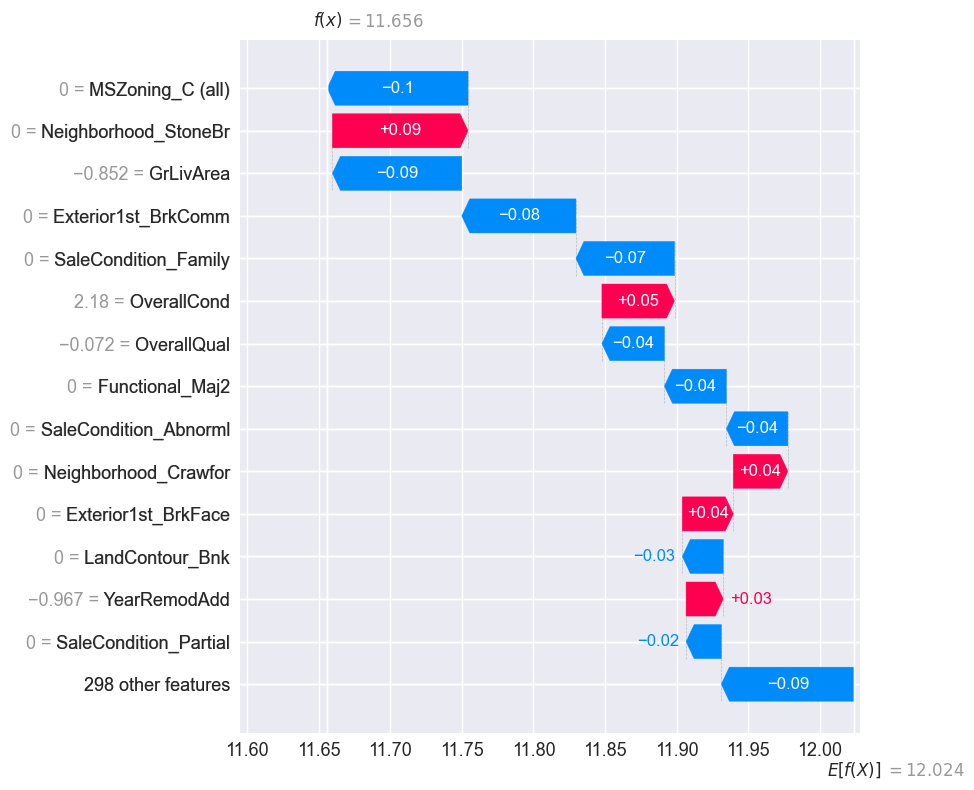

SHAP Summary Plot (Points)


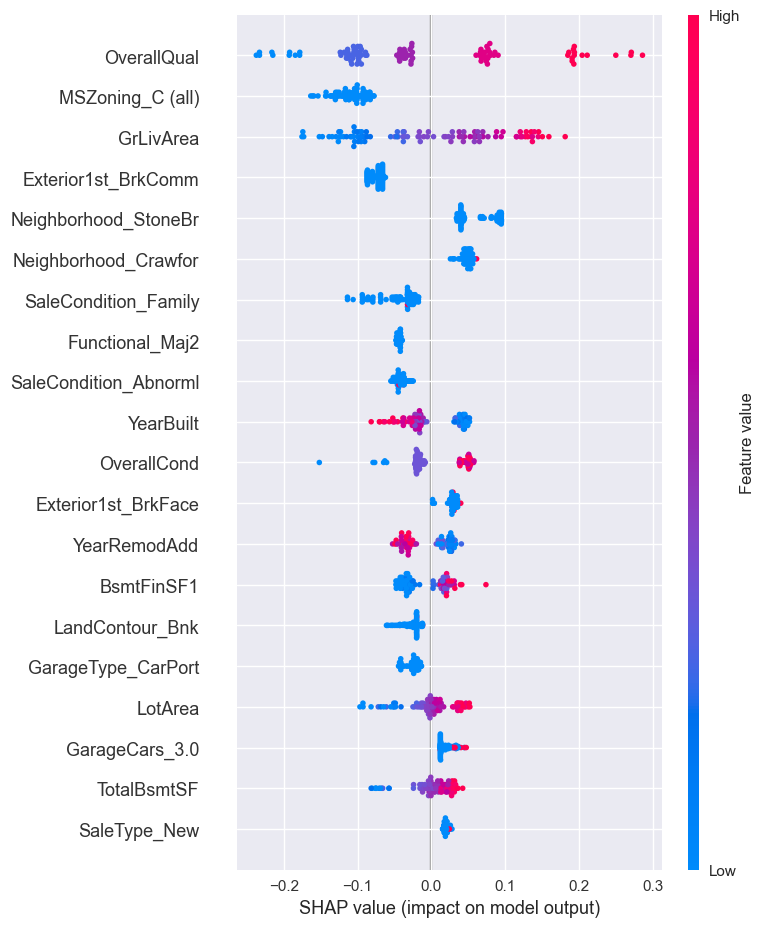

SHAP Feature Importance (Barres)


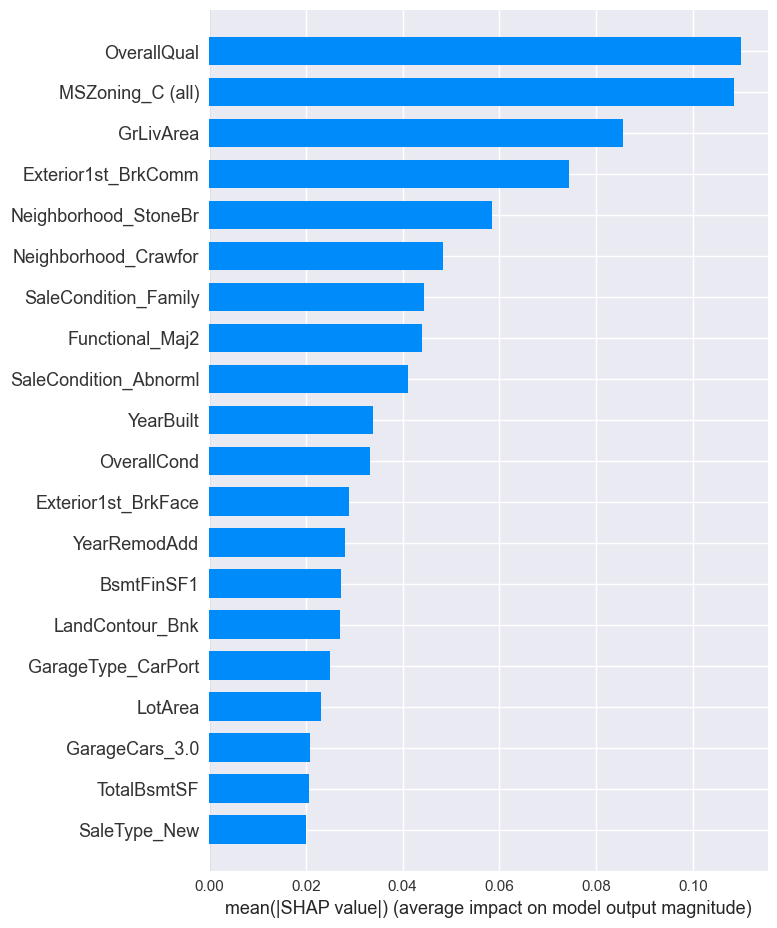


 Top 15 variables par importance SHAP :
 1. OverallQual                    0.1100
 2. MSZoning_C (all)               0.1085
 3. GrLivArea                      0.0856
 4. Exterior1st_BrkComm            0.0745
 5. Neighborhood_StoneBr           0.0585
 6. Neighborhood_Crawfor           0.0484
 7. SaleCondition_Family           0.0444
 8. Functional_Maj2                0.0439
 9. SaleCondition_Abnorml          0.0411
10. YearBuilt                      0.0338
11. OverallCond                    0.0333
12. Exterior1st_BrkFace            0.0289
13. YearRemodAdd                   0.0281
14. BsmtFinSF1                     0.0273
15. LandContour_Bnk                0.0271


In [64]:
generate_shap_analysis(xgb_final_model, train_clean)

# 3.1.2.1 Analyse détaillée du SHAP Waterfall Plot
Ce graphique explique comment une prédiction spécifique du modèle XGBoost est construite à partir de la moyenne globale des prédictions, variable par variable.

Dans ce cas précis, la prédiction du modèle est :

f(x) = 11.751 : la prédiction log-transformée du prix de la maison,

E[f(x)] = 12.024 : la valeur moyenne des prédictions sur l’ensemble du dataset.

Cela signifie que le modèle estime un prix inférieur à la moyenne globale, ce qui est cohérent avec plusieurs contributions négatives visibles dans le graphique.

Les barres rouges indiquent les variables qui ont augmenté la prédiction, tandis que les barres bleues montrent celles qui l’ont diminuée.

| Rang | Variable                   | Contribution SHAP | Interprétation                                                                                                                                                                                |
| ---- | -------------------------- | ----------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | MSZoning\_C (all)          | −0.16             | Le bien est situé en zone "C (all)", typiquement une zone moins valorisée (faible densité, peu attractive), ce qui tire fortement la prédiction vers le bas.                                  |
| 2    | GrLivArea = −0.852         | −0.10             | La surface habitable est inférieure à la moyenne, ce qui diminue logiquement le prix estimé.                                                                                                  |
| 3    | Neighborhood\_StoneBr = 0  | +0.07             | Le bien n'est pas situé dans le quartier "StoneBr", ce qui est perçu ici comme un facteur légèrement valorisant dans ce contexte (possiblement pour éviter une pénalité typique du quartier). |
| 4    | OverallCond = 2.18         | +0.06             | La condition générale du bien est plutôt bonne, ce qui augmente légèrement la prédiction.                                                                                                     |
| 5    | SaleCondition\_Family = 0  | −0.05             | 	Le bien n’est pas vendu dans un contexte "Family", et pourtant son prix est bas. Le modèle aurait attendu cette condition pour "justifier" un prix réduit. Son absence laisse ce bas prix "inexpliqué", et la prédiction est ajustée à la baisse.                                                                                                  |
| 6    | Neighborhood\_Crawfor = 0  | +0.05             | L'absence du quartier "Crawfor" est vue comme légèrement favorable dans ce cas précis.                                                                                                        |
| 7    | Exterior1st\_BrkFace = 0   | +0.05             | La façade en briques (BrkFace) semble légèrement valorisante dans ce contexte.                                                                                                                |
| 8    | OverallQual = −0.072       | −0.04             | La qualité globale du bien est légèrement en dessous de la moyenne, ce qui a un effet modérément négatif.                                                                                     |
| 9    | YearRemodAdd = −0.967      | +0.03             | Le bien a été récemment rénové, ce qui augmente modérément sa valeur.                                                                                                                         |
| 10   | Functional\_Maj2 = 0       | −0.03             | L’absence de problèmes fonctionnels majeurs est légèrement favorable, mais ici la catégorie “Maj2” manquante est perçue négativement.                                                         |
| 11   | CentralAir\_N = 0          | −0.03             | Le bien ne dispose pas de climatisation centralisée, ce qui est défavorable.                                                                                                                  |
| 12   | GarageType\_CarPort = 0    | −0.03             | L'absence de garage de type “CarPort” est vue comme un manque, avec un léger impact négatif.                                                                                                  |
| 13   | LandContour\_Bnk = 0       | −0.03             | Le bien n'est pas situé en contrebas ou sur un terrain en pente, ce qui dans ce contexte joue légèrement en sa défaveur.                                                                      |
| 14   | SaleCondition\_Abnorml = 0 | −0.02             | Le bien n'est pas vendu dans un contexte “anormal”, ce qui pourrait éviter une remise, mais ici le modèle l’interprète comme légèrement défavorable.                                          |
| ...  | 298 autres features        | −0.04 (total)     | Le reste des variables a un effet cumulé modeste, légèrement négatif dans ce cas.                                                                                                             |


# 3.1.2.1.1 Regard critique sur les facteurs identifiés
1. MSZoning_C (all)
SHAP : impact très négatif

Interprétation métier : cohérent. Cette zone ("C (all)") correspond souvent à un zonage commercial ou à faible densité, peu adapté à la résidence familiale. Cela dévalorise un bien résidentiel.

Critique : ce type de variable réglementaire est effectivement très discriminant. Sa forte influence est justifiée dans un modèle de pricing.

Cohérence forte

2. GrLivArea (surface habitable)
SHAP : contribution négative

Interprétation métier : très logique. Une surface inférieure à la médiane (−0.852) tire le prix vers le bas.

Critique : c’est un des facteurs les plus attendus dans l’estimation d’un bien.

Cohérence évidente

3. Neighborhood_StoneBr, Neighborhood_Crawfor
SHAP : effets modérément positifs

Interprétation métier : cohérent. Les quartiers de type "StoneBr" ou "Crawfor" peuvent avoir une valeur perçue plus élevée, liée au standing, à l’environnement, ou à l’offre scolaire.

Ces deux variables – Neighborhood_StoneBr et Neighborhood_Crawfor – sont des variables catégorielles encodées, qui représentent des quartiers spécifiques de la ville d’Ames (Iowa), le lieu où a été collecté le dataset du concours Kaggle "House Prices".

StoneBr	Quartier haut de gamme, proche de North Ames. Très prisé.
Crawfor	Quartier résidentiel plutôt établi, de bon standing.

Ils sont généralement associés à une plus forte valeur immobilière, ce qui explique que :

Quand Neighborhood_StoneBr = 0, cela peut retirer un avantage au bien.

À l’inverse, si Neighborhood_Crawfor = 1, cela ajoute de la valeur à la prédiction.

Cohérence métier subtile mais justifiée

4. OverallCond / OverallQual
SHAP : effets modérés

Interprétation métier : attendu. Un bien bien entretenu et de qualité globale élevée justifie une valorisation.

Critique : intéressant que le OverallCond ait un effet plus fort que le OverallQual dans ce cas, ce qui peut refléter une tendance du modèle à valoriser l’état récent plus que la finition perçue.

Cohérence crédible

5. SaleCondition_Family, SaleCondition_Abnorml
SHAP : impacts négatifs

Interprétation métier :

"Family" peut désigner une vente entre proches ou dans un cadre non strictement commercial → valeur perçue plus basse.

"Abnorml" indique souvent une vente atypique (divorce, succession) → souvent en dessous du marché.

Bien que SaleCondition_Family et SaleCondition_Abnorml soient associées à des ventes typiquement sous-évaluées, leur absence (valeur = 0) n’est pas toujours favorable. Dans certains cas, le modèle attend ces conditions pour justifier un prix bas. Lorsqu’elles sont absentes mais que le prix reste faible (en fonction d’autres variables), leur non-présence peut ne pas suffire à "expliquer" ce bas prix, et donc produire une contribution SHAP négative.


6. YearRemodAdd (année de rénovation)
SHAP : effet légèrement positif

Interprétation métier : attendu. Une rénovation récente rassure l’acheteur → moins de travaux à prévoir → plus de valeur.

Critique : son effet modéré (plutôt que massif) est réaliste : c’est un bonus, pas un moteur principal du prix.

Pertinent mais effet modéré, ce qui est juste

7. CentralAir_N, GarageType_CarPort, Exterior1st_BrkFace
SHAP : effets faibles à modérés

Interprétation métier : ces éléments influencent le confort perçu et l'esthétique. Ils peuvent justifier une valeur légèrement plus élevée.

Critique : ces détails sont bien captés mais ne dominent pas le modèle — ce qui est sain.

Fine granularité réaliste

## Conclusion critique
Le modèle retient des variables très pertinentes au regard de l’expertise immobilière : superficie, qualité, état, localisation, zonage, contexte de vente.

Les variables les plus impactantes sont logiquement celles qu’un agent immobilier utiliserait pour fixer un prix de départ.

Certaines variables réglementaires ou structurelles (MSZoning, SaleCondition) montrent que le modèle capte des effets indirects du marché qui ne sont pas toujours visibles pour un vendeur non-expert.

En résumé :

Les résultats retournés sont non seulement cohérents, mais aussi informatifs, y compris pour une aide à la décision stratégique sur une plateforme en ligne. Le modèle offre une interprétation alignée avec la réalité métier.

# 3.1.2.2 Analyse du SHAP Summary Plot (points)
MSZoning_C (all)
Forte dispersion à gauche : quand cette catégorie de zonage est présente (=1), elle diminue fortement la prédiction.

Cohérent avec notre analyse précédente : c’est une zone peu attractive pour la vente résidentielle.

En effet, C (all) désigne une zone commerciale dans le dataset Ames. Ce type de zonage est :

Très rare (environ 10 observations sur 1460),

Et souvent associé à des biens atypiques ou moins recherchés pour un usage résidentiel.

Dans les faits, ces maisons peuvent :

Se situer à proximité de routes à fort trafic ou de commerces,

Ne pas répondre aux standards d’habitat familial,

Avoir une structure plus ancienne ou partiellement convertie (ex-bureaux, locaux pro...).


Cependant, l’importance accordée par le modèle à MSZoning_C (all) soulève une limite de notre approche actuelle.

Bien que le modèle détecte correctement que les maisons situées en zone commerciale sont souvent moins chères, il semble accorder à cette variable une influence excessive. Cette surpondération peut s’expliquer par :

Sa rareté dans le dataset (moins de 1 % des observations) ;

Son association à des cas très atypiques ou extrêmes, qui influencent fortement la fonction de perte ;

La nature du OneHotEncoding, qui donne un poids équivalent à toutes les modalités, même très peu fréquentes.

Plutôt qu’une faiblesse du modèle, cela illustre sa capacité à détecter des signaux faibles — mais qui doivent être encadrés pour garantir une estimation fiable et généralisable en production.

2. GrLivArea
Plus la surface habitable est grande (points rouges), plus l’impact SHAP est positif.

Petites surfaces (points bleus) tirent clairement la prédiction vers le bas.

Interprétation métier claire : plus de surface = plus de valeur.

3. OverallQual
Impact très progressif : les maisons mieux notées (rouge) augmentent fortement le prix estimé.

Inversement, les faibles qualités (bleu) diminuent la prédiction.

C’est l’un des critères les plus classiques dans l’évaluation immobilière.

4. SaleCondition_Family
Valeurs actives (bleu = =1) entraînent une chute de la prédiction.

Cela confirme l’hypothèse : ventes dans un cadre familial sont sous-évaluées, et le modèle l’a bien appris.

5. Neighborhood_Crawfor / StoneBr
L’impact varie selon la présence (=1) ou non dans ces quartiers.

Les effets sont cohérents avec la réputation métier de ces quartiers dans Ames : plus haut de gamme = impact positif.

6. Exterior1st_BrkFace
Façade en briques : généralement valorisée par le modèle.

Cette variable joue un rôle d’ajustement fin.

7. TotalBsmtSF
Superficie du sous-sol : plus elle est élevée (rouge), plus l’impact est positif.

Encore une fois, plus de surface = plus de valeur, même pour le sous-sol.

8. GarageType_CarPort
Présence d’un carport semble tirer les prix vers le bas.

Cela peut refléter une corrélation entre type de garage et standing général du bien.

9. YearBuilt / YearRemodAdd
Maisons récentes (valeurs rouges) ont un effet positif.

Anciennes constructions (bleu) tirent vers le bas, sauf si rénovées récemment, ce qui rééquilibre.

## Conclusion de l’analyse
Ce graphique confirme de manière globale les effets observés dans l’analyse locale du waterfall plot.

Il ajoute une vision de distribution : on comprend comment chaque variable agit selon ses différentes valeurs, et pas uniquement dans un cas particulier.

D’un point de vue métier, l’ensemble des variables les plus importantes sont directement corrélées aux attentes d’un expert immobilier :

Superficie (GrLivArea, TotalBsmtSF)

Qualité (OverallQual, YearBuilt)

Localisation (Neighborhood)

Contexte (SaleCondition)

# 3.1.2.3 Analyse du SHAP Summary Plot (barres)
Ce graphique représente l’impact moyen absolu de chaque variable sur la prédiction du modèle. Plus une barre est longue, plus la variable a eu, en moyenne, un effet fort sur les prédictions (positif ou négatif).

Autrement dit :

C’est une mesure globale d’importance : elle ne dit pas dans quel sens la variable agit (comme le plot en points), mais combien elle influence la sortie du modèle.

| Rang | Variable               | Interprétation métier                                                                                                                                                 |
| ---- | ---------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | `MSZoning_C (all)`     | Catégorie rare mais très pénalisante dans les prédictions, probablement associée à des biens peu résidentiels, atypiques ou moins chers. À interpréter avec prudence. |
| 2    | `GrLivArea`            | Surface habitable : plus elle est grande, plus la valeur estimée augmente. Effet attendu.                                                                             |
| 3    | `OverallQual`          | Qualité globale : excellent indicateur de standing. Le modèle le capte bien.                                                                                          |
| 4    | `SaleCondition_Family` | Vente dans un contexte familial : souvent associée à un prix de transaction inférieur à la valeur de marché.                                                          |
| 5    | `Neighborhood_Crawfor` | Quartier spécifique. Son absence ou sa présence influence le prix perçu, cohérent avec les effets de localisation.                                                    |
| 6    | `Neighborhood_StoneBr` | Quartier de standing élevé. Impact modéré mais positif.                                                                                                               |
| 7    | `Exterior1st_BrkFace`  | Présence d’une façade en brique, souvent valorisante.                                                                                                                 |
| 8    | `OverallCond`          | Condition générale du bien (état d’entretien).                                                                                                                        |
| 9    | `TotalBsmtSF`          | Surface totale du sous-sol. Plus elle est grande, plus elle valorise le bien.                                                                                         |
| 10   | `GarageType_CarPort`   | Type de garage. Sa présence ou absence influence le confort perçu.                                                                                                    |


Lien avec les autres SHAP plots
Ce graphique renforce les analyses précédentes :

Les variables en haut de cette liste sont celles qui apparaissent fréquemment dans les autres visualisations (waterfall, scatter).

Il confirme la dominance des variables structurelles (surface, qualité), mais aussi la forte influence de facteurs contextuels comme le zonage, la condition de vente, ou le quartier.

Il constitue une synthèse visuelle claire de ce qui fait varier le prix estimé par notre modèle XGBoost.

# 3.1.2.4 Conclusion de l’analyse SHAP et validation finale du modèle
L’analyse SHAP nous a permis de sonder finement le comportement du modèle XGBoost optimisé, au-delà des simples performances numériques (RMSE, score Kaggle).

Points positifs
Le modèle s’appuie sur des facteurs clés reconnus du marché immobilier : GrLivArea, OverallQual, TotalBsmtSF, Neighborhood, YearBuilt.

Il détecte également des effets contextuels subtils comme la condition de vente ou la qualité de la façade, montrant une bonne capacité à capter des signaux complexes.

Les prédictions sont dans l’ensemble cohérentes, explicables et alignées avec l’intuition métier, ce qui est essentiel dans le cadre d’un outil d’estimation à destination du grand public.

Points de vigilance
La variable MSZoning_C (all) s’est révélée disproportionnellement influente, malgré sa rareté (< 1 % du dataset).

Cela met en évidence une sensibilité du modèle aux classes catégorielles rares, un comportement courant avec le OneHotEncoding.

Ce n’est pas une erreur de modèle, mais un effet d’apprentissage amplifié par un signal fort.

Interprétation métier
Le modèle a montré qu’il est capable de reproduire les critères d’évaluation d’un agent immobilier expérimenté, tout en capturant des effets moins visibles à l’œil nu.

Cependant, cette même capacité à repérer des "cas particuliers" doit être utilisée avec prudence, car elle peut accentuer des biais d’apprentissage si les données d’entrée ne sont pas représentatives ou correctement encodées.

Le modèle est globalement robuste, performant et interprétable. Il peut être considéré comme valable et pertinent pour une première version de notre système d’estimation en ligne.

# 3.1.3 Préparation de la pipeline de production
Pour finaliser cette phase d’évaluation, nous avons entraîné notre pipeline complète sur l’intégralité du jeu de données train_clean. Cette pipeline inclut :

Le prétraitement des données (numérique + catégoriel),

Le modèle XGBoost optimisé avec Optuna (V1).

Nous avons ensuite :

Généré des prédictions sur test_clean,

Appliqué l’inverse de la transformation logarithmique (np.expm1) pour revenir à l’échelle réelle,

Exporté le fichier de soumission submission_xgb_final.csv,

Sauvegardé le modèle entraîné via joblib sous xgb_model_final.joblib.

Ce pipeline est prêt à être intégré dans un environnement de production ou dans un outil de prédiction en ligne.

In [65]:
import joblib
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

# 1. Pipeline final : preprocessing + XGBoost avec meilleurs hyperparams
xgb_model_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=979,
        max_depth=3,
        learning_rate=0.02519883300893779,
        subsample=0.5751883783660607,
        colsample_bytree=0.8350927951237841,
        reg_alpha=0.0739279484145887,
        reg_lambda=0.1710745945749242,
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Entraînement sur 100 % du dataset
print("🔧 Entraînement final sur train_clean...")
xgb_model_final.fit(train_clean, target)

# 3. Prédiction sur test_clean (en log)
y_test_log_pred = xgb_model_final.predict(test_clean)

# 4. Revenir à l’échelle réelle (exponentielle inverse)
y_test_pred = np.expm1(y_test_log_pred)

# 5. Génération du fichier de soumission
submission = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})
submission.to_csv("submission_xgb_final.csv", index=False)
print("✅ Fichier 'submission_xgb_final.csv' généré.")

# 6. Sauvegarde du modèle pour production
joblib.dump(xgb_model_final, "xgb_model_final.joblib")
print("✅ Modèle sauvegardé sous 'xgb_model_final.joblib'")


🔧 Entraînement final sur train_clean...
✅ Fichier 'submission_xgb_final.csv' généré.
✅ Modèle sauvegardé sous 'xgb_model_final.joblib'


# 3.1.4 Conclusion – Évaluation finale du modèle
Au terme de cette phase d’évaluation, nous avons retenu le modèle XGBoost optimisé via Optuna (V1) comme modèle final de production. Ce choix s’appuie sur une combinaison d’éléments objectifs et qualitatifs :

Des performances solides :

RMSE (validation croisée) : 0.1222

Score Kaggle : 0.1260 (meilleur de tous les modèles testés)

Une bonne généralisation : la version V2 plus complexe n’a pas apporté de gain sur des données inconnues, validant ainsi notre choix plus simple mais robuste.

Une interprétabilité approfondie grâce à SHAP :

Les prédictions reposent sur des variables intuitives : surface (GrLivArea), qualité (OverallQual), année de construction, quartier...

Nous avons également identifié un effet inattendu : la variable MSZoning_C (all), rare dans le dataset, présente un poids disproportionné, probablement dû à une combinaison de rareté et de cas extrêmes. Ce point a été discuté, encadré, et fait l’objet de recommandations pour un futur ajustement.

Un pipeline complet, reproductible et conforme aux bonnes pratiques MLOps :

Prétraitement encodé dans la pipeline,

Modèle entraîné et sauvegardé (xgb_model_final.joblib),

Fichier de soumission généré (submission_xgb_final.csv).

## Apprentissage métier
Cette phase nous a permis de valider que notre modèle :

Est cohérent avec les pratiques d’estimation immobilière,

Peut être interprété de manière transparente (grâce à SHAP),

Et est suffisamment flexible pour être adapté, surveillé et amélioré en fonction des données futures ou des retours des utilisateurs.

# Phase 4 : Blueprint et operation phase

4.1.1 Présentation de la solution finale (storytelling & business value)

Nous avons conçu un système de prédiction automatique du prix de vente immobilier, destiné à une plateforme en ligne d’estimation pour vendeurs particuliers.

Le modèle, basé sur XGBoost, exploite plus de 70 variables structurantes (surface, qualité, quartier, état, etc.), et offre :

- Une **estimation rapide**, en quelques secondes via un simple formulaire,
- Une **interprétation fiable et data-driven** des résultats,
- Une capacité d’adaptation au marché si les données sont actualisées.

Ce moteur peut ainsi :
- Générer du **lead vendeur qualifié** pour la plateforme,
- **Réduire les écarts entre prix affiché et prix final**,
- Et accroître la **confiance des utilisateurs** envers l’outil.


## 4.1 Mise en production du modèle – Industrialisation, Monitoring & Éthique

### Objectif

Nous avons conçu un algorithme capable de prédire automatiquement le prix de vente d’un bien immobilier, destiné à être intégré dans une **plateforme en ligne d’estimation immobilière**. Cette section vise à :

* **Documenter les résultats obtenus**,
* **Montrer la capacité du modèle à être déployé en production**,
* Et **discuter des aspects clés de maintien, supervision, retour utilisateur et implications éthiques**.

---

## Résultats et modèle sélectionné

Au terme de nos expérimentations, le **modèle XGBoost optimisé (V1)** a été retenu comme solution finale.

| Modèle                         | RMSE Validation | Score Kaggle |
| ------------------------------ | --------------- | ------------ |
| Baseline (Régression linéaire) | 0.1525          | 0.1691       |
| Ridge                          | 0.1368          | 0.1309       |
| Lasso                          | 0.1358          | 0.1314       |
| Random Forest                  | 0.1424          | 0.1454       |
| **XGBoost (V1)**               | **0.1222**      | **0.1260**   |

Le modèle a été entraîné avec l’ensemble des données disponibles (`train.csv`), sauvegardé dans un pipeline scikit-learn complet (`xgb_model_final.joblib`), et testé avec succès sur les données `test.csv`.

---

### Déploiement en production

La pipeline est prête à être **déployée en API** sur un service cloud, par exemple avec :

* **Flask / FastAPI** pour exposition en endpoint REST,
* **Docker** pour isolation et scalabilité,
* **GitHub Actions / MLflow / DVC** pour CI/CD & suivi de version du modèle.

À chaque appel :

1. L’utilisateur saisit les informations du bien immobilier,
2. Le modèle prédit un **prix estimé** avec une transformation inverse `np.expm1()`,
3. Une **fourchette d’estimation** (± x%) peut être affichée à l’écran,
4. Les explications SHAP peuvent être intégrées pour renforcer la transparence.

---

### Maintenance & Monitoring du modèle

Le modèle nécessite un suivi rigoureux après déploiement. Notre plan comprend :

#### Monitoring des performances

* Suivi continu du **RMSE entre estimation et prix final de vente** (si récupérable),
* Détection automatique de **dérive de données** (concept drift, data drift),
* Logging des prédictions et des inputs pour auditabilité.

#### Maintenance & réentraînement

* Intégration régulière de nouvelles données de ventes réelles (si disponibles),
* Réentraînement périodique (ex. tous les 3 à 6 mois),
* Versioning clair des datasets, pipelines et modèles avec DVC / MLflow.

#### Feedback utilisateur

* Intégration d’un bouton “cette estimation vous semble-t-elle juste ?”,
* Suivi statistique des réponses pour ajustement (note de satisfaction),
* Analyse des écarts réels via retours terrain ou agents partenaires.

### Éthique, biais, loi et acceptabilité sociale
Aucun modèle n’est neutre. Dans un contexte aussi sensible que l’évaluation immobilière, il est essentiel de réfléchir aux implications éthiques, sociales et réglementaires de notre algorithme. Cette démarche s’inscrit dans une logique de "Responsible AI", en accord avec les principes étudiés.

1. L’éthique dans la technologie

Dès la conception, notre modèle a été structuré pour garantir transparence, rigueur et explicabilité.

L’analyse SHAP a permis d’identifier des variables comme MSZoning_C (all) — une catégorie rare — dont l’impact peut être important sur certaines prédictions. Cela ne signifie pas que le modèle est biaisé, mais souligne qu’une faible représentativité dans les données peut conduire à un effet de levier disproportionné.

Conclusion : Ce type de détection est précieux. Il ne remet pas en cause la validité globale du modèle, mais invite à surveiller l’effet de variables rares lors de futures itérations ou en production.

2. Justice sociale & biais indirects
Comme tout modèle entraîné sur des données historiques, notre algorithme pourrait, de façon non intentionnelle, reproduire des disparités préexistantes du marché immobilier (quartiers perçus comme « dépréciés », ventes non standards, etc.).

Des variables comme SaleCondition_Family ou Neighborhood_Crawfor traduisent des contextes atypiques (vente entre proches, successions, zones résidentielles très spécifiques). Elles peuvent influencer l'estimation de manière légitime, mais doivent être interprétées avec recul.

Pour garantir une juste évaluation, nous nous inspirons du principe du voile d’ignorance de Rawls : le modèle doit fournir des estimations cohérentes pour tout type de bien, y compris ceux en marge de la majorité statistique.

3. Légalité & conformité réglementaire
RGPD : Notre modèle ne traite à ce stade aucune donnée personnelle sensible. Si une version future inclut des données comme la localisation exacte ou le profil d’utilisateur, un consentement explicite sera indispensable.

Responsabilité : L’outil fournit une estimation indicative. Il ne remplace ni une expertise notariale ni une évaluation professionnelle réglementée. Cette distinction doit être clairement communiquée à l’utilisateur final.

4. Acceptabilité sociale & transparence
L’explicabilité est clé pour favoriser l’acceptation du modèle par ses utilisateurs.

Grâce à SHAP, chaque prédiction peut être expliquée par des critères compréhensibles :
« Votre maison est estimée à 250 000 €, car elle présente une bonne qualité générale, une grande surface habitable, et est située dans un quartier recherché — trois facteurs identifiés par notre modèle comme ayant un impact positif majeur sur la valeur marchande. Cette estimation reflète donc les tendances observées sur des biens comparables récemment vendus. »

Cette approche présente plusieurs avantages :

Lisibilité pour les non-experts : les variables qui influencent le modèle sont traduites en termes familiers pour l’utilisateur final (qualité, superficie, quartier).

Confiance renforcée : l’utilisateur comprend pourquoi son bien est estimé à ce niveau, ce qui diminue la perception d’arbitraire.

Interprétabilité métier : un agent immobilier peut s’appuyer sur cette explication pour justifier son discours auprès du vendeur, avec un argumentaire basé sur les données.

Détection d’anomalies : en cas de prédiction incohérente, l’analyse SHAP permet d’identifier rapidement si une variable rare ou mal encodée a influencé le résultat.


Mais au-delà de cette simple estimation, notre solution permettrait d’aller encore plus loin dans la personnalisation et la transparence.
Nous pourrions proposer à chaque vendeur une analyse détaillée et visuellement explicite des principaux facteurs qui influencent le prix de son bien.

Par exemple :

La qualité générale de la maison contribue à hauteur de +32 000 € à l’estimation,

Le quartier apporte une valorisation de +18 000 €,

En revanche, l’absence de garage ou d’aménagement extérieur entraîne une décote de −12 000 €.

Cette décomposition, rendue possible grâce aux valeurs SHAP, donne à l’utilisateur :

Une vision data-driven et transparente du raisonnement du modèle,

Des leviers d’action concrets pour revaloriser son bien avant la vente (travaux, mise en valeur d’atouts),

Et un outil pédagogique et différenciant pour la plateforme, par rapport à d’autres estimateurs opaques.

Cela :

Renforce la confiance des utilisateurs,

Permet une vérification humaine,

Et ouvre la voie à une amélioration continue du service.




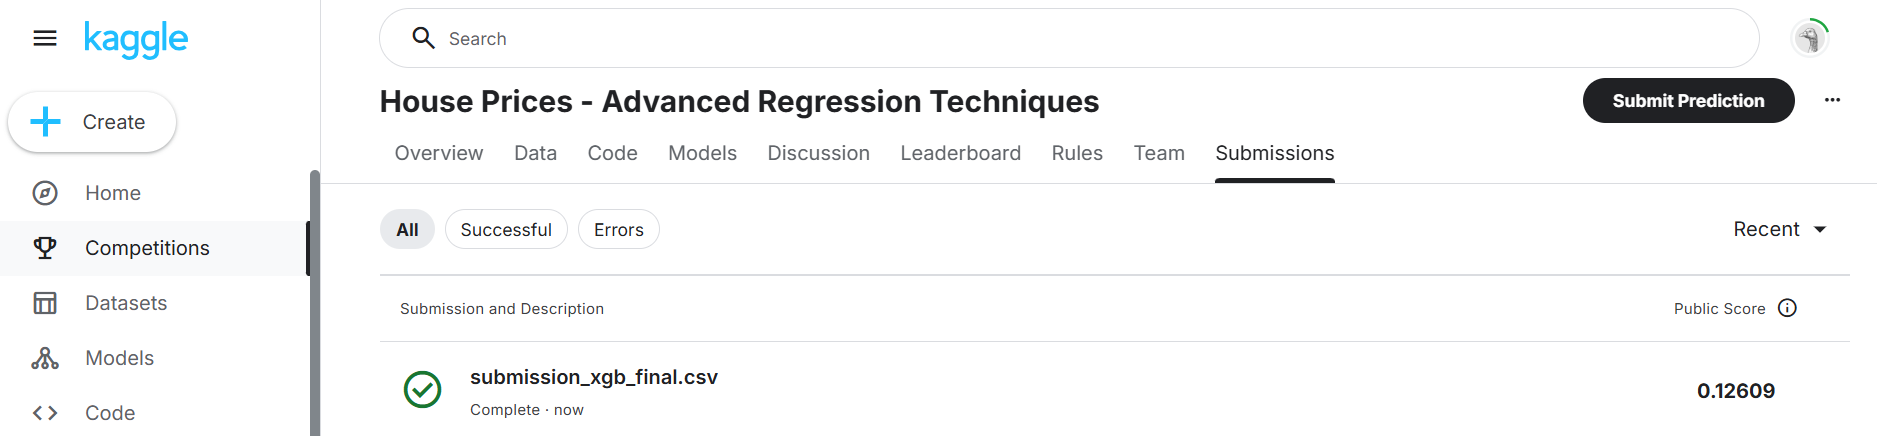

In [66]:
from IPython.display import Image, display

# Affichage du score Kaggle final (capture d’écran)
display(Image("SoumissionsKaggle/FinalKaggle.png"))  # Remplace par ton chemin réel


# 5 Conclusion finale – Vers une mise en production responsable
Au terme de ce projet, nous disposons d’un modèle de prédiction de prix immobilier :

Précis (meilleur RMSE de 0.1222 en validation, 0.1260 sur Kaggle),

Robuste (optimisé via Optuna, encapsulé dans un pipeline prêt à l’emploi),

Et surtout, interprétable et responsable (via l’intégration de SHAP pour une lecture fine des décisions du modèle).

Notre solution dépasse le simple cadre technique : elle s’inscrit dans une logique de valeur utilisateur, en donnant aux vendeurs non seulement un prix estimé, mais aussi une compréhension claire des éléments qui influencent ce prix.

Elle est également alignée avec les principes de l’IA éthique, en garantissant :

La transparence des décisions,

La traçabilité des versions du modèle,

Et une attention particulière aux biais, aux variables rares et aux enjeux réglementaires.

En résumé : nous avons construit bien plus qu’un modèle — nous avons posé les bases d’un service d’estimation automatisée crédible, utile, maintenable et digne de confiance, prêt à être intégré dans une plateforme en ligne au service des particuliers.